# Improved Root Count Prediction Pipeline

This notebook implements an **improved** node classification pipeline for predicting the **number of rational roots** (totalZero) for polynomial nodes (Dnode).

## Key Improvements Over Baseline

1. **Expanded Feature Set (16D)**: wNum, degree, determined, 5 coefficients, 5 statistics, Set Union Ratio (n, d, mu_ratio)
2. **DepthAwareGATv2**: Skip connections + Jumping Knowledge (JKNet) to prevent over-smoothing
3. **Focal Loss**: Down-weights easy examples, focuses on hard minority classes
4. **Class Weights**: Inverse frequency weighting to handle imbalanced root count distribution
5. **Proper Metrics**: Uses Macro F1 and Balanced Accuracy (not weighted F1 which hides class imbalance)

## Pipeline Steps
1. Load environment and connect to Neo4j
2. Load graph data with 16D features (base + coefficients + statistics + set_union)
3. Train models: DepthAwareGAT, DepthAwareGATv2, FocalLossClassifier, CORAL
4. Evaluate with Macro F1 (treats all classes equally)
5. Generate predictions and write back to Neo4j


In [1]:
# Force reload of graph_label_prediction modules to pick up code changes
# Run this cell if you get ImportError for new classes (DepthAwareGATv2, FocalLossClassifier)
import importlib
import sys

# Remove cached modules
modules_to_reload = [m for m in sys.modules.keys() if m.startswith('graph_label_prediction')]
for module in modules_to_reload:
    del sys.modules[module]

print(f"✓ Cleared {len(modules_to_reload)} cached modules")
print("  Now run the imports cell below to reload with latest code")


✓ Cleared 0 cached modules
  Now run the imports cell below to reload with latest code


## 1. Imports and Setup

**Note**: If you get an `ImportError` for `DepthAwareGATv2` or `FocalLossClassifier`, run the reload cell below first to clear cached modules.


In [2]:
import os
import sys
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Add parent directory to path for pipeline modules
# Notebook is in ml/graph_label_prediction/workbooks/, need to go up 2 levels to reach ml/
ml_path = Path('.').absolute().parent.parent
if str(ml_path) not in sys.path:
    sys.path.insert(0, str(ml_path))

# Add neo4j directory to path for neo4jClient
neo4j_path = ml_path / 'neo4j'
if str(neo4j_path) not in sys.path:
    sys.path.insert(0, str(neo4j_path))

# Import Neo4j client
from neo4jClient import Neo4jClient

# Import pipeline components
from graph_label_prediction.python_model.core.data_loader import GraphDataLoader
from graph_label_prediction.python_model.core.models import (
    get_model, 
    DepthAwareGAT, 
    DepthAwareGATv2,      # Anti-collapse GAT with skip connections + JKNet
    FocalLossClassifier,   # Focal loss model for class imbalance
    MLPClassifier,         # Baseline: no graph structure
    GraphSAGEClassifier,   # Sample & aggregate neighborhood features
)
from graph_label_prediction.python_model.core.trainer import NodeClassificationTrainer, train_and_evaluate
from graph_label_prediction.python_model.core.predictor import NodePredictor, predict_and_write
from graph_label_prediction import config

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Spectral PE dimensions: {config.SPECTRAL_PE_DIM}")
print(f"Attention heads: {config.NUM_ATTENTION_HEADS}")
print("✓ Imports successful")


PyTorch version: 2.9.1+cpu
CUDA available: False
Spectral PE dimensions: 8
Attention heads: 4
✓ Imports successful


## 2. Load Environment Variables


In [3]:
# Load environment variables from .env file
env_paths = [Path('.env'), Path('../.env'), Path('../../.env')]

for env_path in env_paths:
    if env_path.exists():
        load_dotenv(env_path, override=True)
        print(f"✓ Loaded .env from: {env_path.absolute()}")
        break

# Get connection parameters
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE", "neo4j")

print(f"\nConnection Configuration:")
print(f"  URI: {NEO4J_URI}")
print(f"  User: {NEO4J_USER}")
print(f"  Password: {'*' * len(NEO4J_PASSWORD) if NEO4J_PASSWORD else 'NOT SET'}")
print(f"  Database: {NEO4J_DATABASE}")


✓ Loaded .env from: c:\Users\tomas\JavaProjects\Aibeceles\ml\graph_label_prediction\workbooks\..\..\.env

Connection Configuration:
  URI: bolt://localhost:7687
  User: neo4j
  Password: ***********
  Database: d5seed1


## 3. Connect to Neo4j


In [4]:
try:
    client = Neo4jClient(
        uri=NEO4J_URI,
        user=NEO4J_USER,
        password=NEO4J_PASSWORD
    )
    print("✓ Neo4j client initialized successfully")
    
    # Test connection
    test_query = "MATCH (n:Dnode) RETURN count(n) AS total_nodes"
    result = client.run_query(test_query, NEO4J_DATABASE)
    print(f"✓ Database contains {result['total_nodes'].iloc[0]} Dnode nodes")
    
except ConnectionError as e:
    print(f"✗ Connection failed: {e}")
    raise


✓ Neo4j client initialized successfully
✓ Database contains 3024769 Dnode nodes


## 4. Load Graph Data with Spectral Positional Encodings


In [5]:
# Initialize data loader with filtering enabled
print(f"Graph Filtering Configuration:")
print(f"  Filtering enabled: {config.USE_GRAPH_FILTERING}")
if config.USE_GRAPH_FILTERING:
    print(f"  pArrayList constraint: [{config.PARRAY_MIN}, {config.PARRAY_MAX})")
    print(f"  Max nodes for spectral PE: {config.MAX_NODES_FOR_SPECTRAL_PE:,}")

loader = GraphDataLoader(client, NEO4J_DATABASE, use_filtering=config.USE_GRAPH_FILTERING)

# Load graph into PyG format (includes spectral PE computation if feasible)
print("\nLoading graph data from Neo4j...")
data = loader.load()

# Display graph statistics
stats = loader.get_graph_stats(data)
print(f"\n✓ Graph loaded successfully!")
print(f"\nFiltered Graph Statistics:")
print(f"  Nodes: {stats['num_nodes']:,}")
print(f"  Edges: {stats['num_edges']:,} (undirected)")
print(f"  Features: {stats['num_features']} ({config.NUM_BASE_FEATURES} base + {config.NUM_COEFFICIENT_FEATURES} coeff + {config.NUM_STATISTICAL_FEATURES} stats + {config.NUM_SET_UNION_FEATURES} set_union + {config.SPECTRAL_PE_DIM} spectral PE)")
print(f"  Density: {stats['density']:.6f}")
print(f"\nRoot Count Distribution (totalZero):")
for root_count, count in sorted(stats['class_distribution'].items()):
    pct = count / stats['num_nodes'] * 100
    print(f"  {root_count} roots: {count:>8,} nodes ({pct:>5.1f}%)")


Graph Filtering Configuration:
  Filtering enabled: True
  pArrayList constraint: [0, 7)
  Max nodes for spectral PE: 100,000

Loading graph data from Neo4j...
Using filtered queries (pArrayList ∈ [0, 7))...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }', position=<SummaryInputPosition line=4, column=1, offset=29>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 29, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (dd:Dnode)   \nWITH dd\nCALL {\n     WITH dd\n     MATCH (dd)-[:CreatedBye]->(cb)   // and constrain d against all pArrays.\n     //WHERE all(x IN cb.pArrayList WHERE x >= 0 AND x < 7 )\n     WHERE ( all(x IN c

Label mapping: 3 classes present [0, 1, 2] -> [0..2]


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }', position=<SummaryInputPosition line=4, column=1, offset=24>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 24, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (d:Dnode)\nWITH d\nCALL {\n     WITH d\n     MATCH (d)-[:CreatedBye]->(cb)   // and constrain d against all pArrays.\n     //WHERE all(x IN cb.pArrayList WHERE x >= 0 AND x < 7)\n     WHERE ( all(x IN cb.pArrayLi

Computing spectral positional encodings for 206 nodes...
  Feature dim: 25 (17 base+coeff+stats+set_union + 8 spectral PE)

✓ Graph loaded successfully!

Filtered Graph Statistics:
  Nodes: 206
  Edges: 205 (undirected)
  Features: 25 (3 base + 6 coeff + 5 stats + 3 set_union + 8 spectral PE)
  Density: 0.009709

Root Count Distribution (totalZero):
  0 roots:        2 nodes (  1.0%)
  1 roots:       20 nodes (  9.7%)
  2 roots:      184 nodes ( 89.3%)


## 4.5 Analyze Filtering Effect

Compare the filtered graph to the full database to understand what was kept/removed.


In [6]:
# Query full database size for comparison
full_size_query = "MATCH (n:Dnode) RETURN count(n) AS total"
full_result = client.run_query(full_size_query, NEO4J_DATABASE)
full_size = full_result['total'].iloc[0]

print("Filtering Analysis:")
print("=" * 60)
print(f"Full database size: {full_size:,} nodes")
print(f"Filtered graph size: {stats['num_nodes']:,} nodes")
print(f"Reduction: {(1 - stats['num_nodes']/full_size)*100:.1f}%")
print(f"Kept: {(stats['num_nodes']/full_size)*100:.1f}% of original")

# Check if spectral PE was computed
has_spectral = data.x.shape[1] > 1 and torch.abs(data.x[:, 1:]).sum() > 0
print(f"\nSpectral PE computed: {has_spectral}")
if has_spectral:
    print(f"  ✓ Graph size suitable for spectral methods")
else:
    print(f"  ✗ Graph still too large or spectral computation failed")
    print(f"  → Using depth-aware attention + class weights only")


Filtering Analysis:
Full database size: 3,024,769 nodes
Filtered graph size: 206 nodes
Reduction: 100.0%
Kept: 0.0% of original

Spectral PE computed: True
  ✓ Graph size suitable for spectral methods


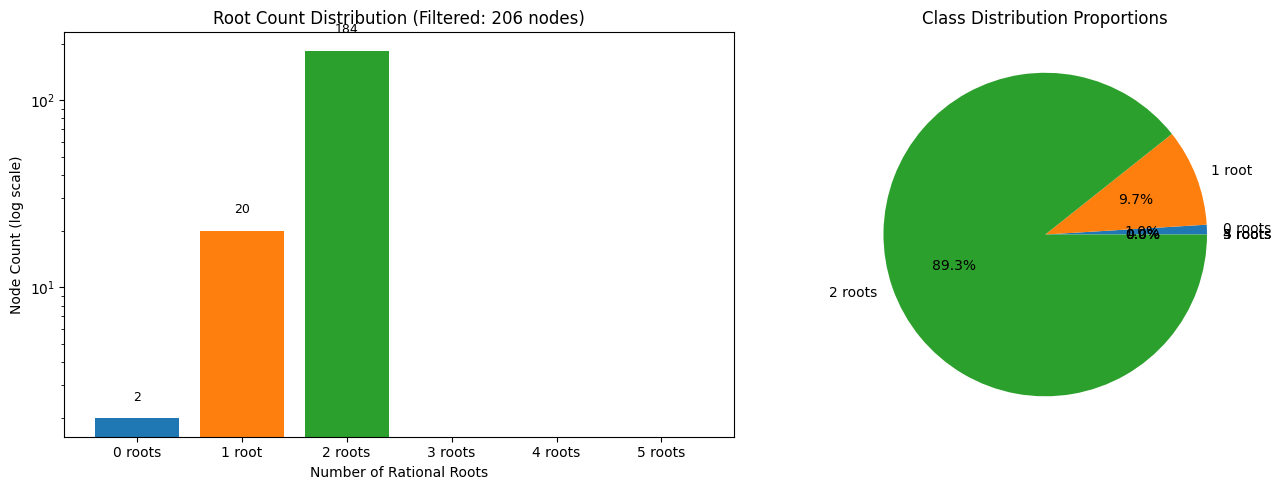


Class Imbalance Ratio: 92.0:1 (majority:minority)


In [7]:
# Visualize class distribution with filtering info
class_names = config.CLASS_NAMES
class_counts = [stats['class_distribution'].get(i, 0) for i in range(config.NUM_CLASSES)]

# Generate colors dynamically based on number of classes
num_classes = len(class_names)
if num_classes <= 10:
    cmap = plt.cm.tab10
    colors = [cmap(i) for i in range(num_classes)]
else:
    cmap = plt.cm.tab20
    colors = [cmap(i) for i in range(num_classes)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart (log scale to show all classes)
ax1 = axes[0]
bars = ax1.bar(class_names, class_counts, color=colors)
ax1.set_xlabel('Number of Rational Roots')
ax1.set_ylabel('Node Count (log scale)')
ax1.set_title(f'Root Count Distribution (Filtered: {stats["num_nodes"]:,} nodes)')
ax1.set_yscale('log')

for bar, count in zip(bars, class_counts):
    if count > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.2, 
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

# Pie chart showing proportions
ax2 = axes[1]
ax2.pie(class_counts, labels=class_names, autopct='%1.1f%%', colors=colors)
ax2.set_title('Class Distribution Proportions')

plt.tight_layout()
plt.show()

# Compute imbalance ratio
max_class = max(class_counts)
min_class = min(c for c in class_counts if c > 0)
print(f"\nClass Imbalance Ratio: {max_class / min_class:.1f}:1 (majority:minority)")


## 5. Train Models (Orchestrated)

Uses `ExperimentRunner` to sweep over model architectures, loss functions,
and activations in a single call. Each experiment shares the same
train/val/test split for fair comparison.

Edit the `configs` list or use `ExperimentRunner.grid()` to define
the experiment matrix.


In [8]:
from graph_label_prediction.python_model.core.experiment import (
    ExperimentConfig, ExperimentRunner, ExperimentReport,
)

runner = ExperimentRunner(data, trainer_kwargs={'use_class_weights': True})

# ── Explicit experiment list ──────────────────────────────────────────
configs = [
    ExperimentConfig(name="GraphSAGE-CE-relu",    model_name="graphsage",        loss_type="ce"),
    ExperimentConfig(name="GraphSAGE-Focal-relu",  model_name="graphsage",        loss_type="focal"),
    ExperimentConfig(name="MLP-CE-relu",           model_name="mlp",              loss_type="ce"),
    ExperimentConfig(name="GAT-CE-elu",            model_name="depth_aware_gat",  loss_type="ce",    activation="elu"),
    ExperimentConfig(name="GAT-Focal-elu",         model_name="depth_aware_gat",  loss_type="focal", activation="elu"),
    ExperimentConfig(name="CORAL-CE-relu",         model_name="coral",            loss_type="ce"),
]

# ── Optional: add a grid sweep ────────────────────────────────────────
# configs += ExperimentRunner.grid(
#     models=["graphsage", "depth_aware_gat"],
#     losses=["ce", "focal"],
#     activations=["relu", "elu"],
#     weight_decays=[1e-3],
# )

report = runner.run_all(configs, verbose=True)


Stratified split (guaranteed class coverage):
  Train: 137 | Val: 30 | Test: 41
  Train classes: [0, 1, 2]
  Val classes: [0, 1, 2]
  Test classes: [0, 1, 2]
Class weights (sqrt inverse frequency, normalized):
  0 roots: 1.931
  1 root: 0.823
  2 roots: 0.245
Training configuration:
  Device: cpu
  Train/Test split: 80% / 20%
  Train nodes: 137
  Test nodes: 41
  Class weighting: Enabled


In [9]:
# ── Save report and export JSON ───────────────────────────────────────
from pathlib import Path

metrics_dir = Path("evaluation_metrics")
metrics_dir.mkdir(exist_ok=True)
report.to_json(metrics_dir / f"experiment_report_{report.run_id}.json")
print(f"\nReport saved to {metrics_dir / f'experiment_report_{report.run_id}.json'}")

# ── Display comparison table ──────────────────────────────────────────
df = report.to_dataframe()
df


Training DepthAwareGAT (Spectral PE + Depth Attention + Class Weights)
Epoch 000 | Loss: 0.2455 | Train Macro F1: 0.3160 | Val Macro F1: 0.2667
Epoch 010 | Loss: 0.1965 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 020 | Loss: 0.1741 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 030 | Loss: 0.1635 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 040 | Loss: 0.1489 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 050 | Loss: 0.1383 | Train Macro F1: 0.3020 | Val Macro F1: 0.2893
Epoch 060 | Loss: 0.1717 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 070 | Loss: 0.1684 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Early stopping at epoch 71

DepthAwareGAT Results:
  Test Macro F1: 0.2973 (treats classes equally)
  Test Balanced Acc: 0.3333
  Test MAE: 0.2195 roots
  (Weighted F1: 0.7179 - for comparison only)


## 6. Best Model Analysis

Detailed diagnostics for the best-performing experiment from the sweep above.


In [10]:
# Get the best model + its info for downstream analysis
best_info = report.best()
best_model = report.best_model()
trainer = runner.trainer  # expose trainer for confusion matrices etc.

print(f"Best experiment: {best_info['name']}")
print(f"  Macro F1:      {best_info['test_macro_f1']:.4f}")
print(f"  Balanced Acc:  {best_info['test_balanced_acc']:.4f}")
print(f"  MAE:           {best_info['test_mae']:.4f}")

print(f"\nDetailed Classification Report ({best_info['name']}):")
print("=" * 60)
print(trainer.get_detailed_report(best_model))

print(f"\nConfusion Matrix ({best_info['name']}):")
trainer.print_confusion_matrix(best_model, split='test', normalize=True)

print(f"\nPrediction Distribution:")
trainer.print_prediction_diagnostics(best_model)


Training DepthAwareGATv2 (Skip Connections + JKNet + 2 Layers)
Epoch 000 | Loss: 0.1911 | Train Macro F1: 0.0495 | Val Macro F1: 0.0417
Epoch 010 | Loss: 0.2502 | Train Macro F1: 0.0495 | Val Macro F1: 0.0417
Epoch 020 | Loss: 0.2502 | Train Macro F1: 0.0495 | Val Macro F1: 0.0417
Epoch 030 | Loss: 0.2502 | Train Macro F1: 0.0495 | Val Macro F1: 0.0417
Epoch 040 | Loss: 0.2502 | Train Macro F1: 0.0495 | Val Macro F1: 0.0417
Epoch 050 | Loss: 0.2502 | Train Macro F1: 0.0495 | Val Macro F1: 0.0417
Epoch 060 | Loss: 0.2502 | Train Macro F1: 0.0495 | Val Macro F1: 0.0417
Epoch 070 | Loss: 0.2502 | Train Macro F1: 0.0495 | Val Macro F1: 0.0417
Early stopping at epoch 70

DepthAwareGATv2 Results:
  Test Macro F1: 0.0972 (treats classes equally)
  Test Balanced Acc: 0.3333
  Test MAE: 0.8293 roots
  (Weighted F1: 0.0498 - for comparison only)


(This cell intentionally left empty after orchestration refactor.)


In [11]:
# (Superseded by ExperimentRunner -- see section 5)


Training FocalLossClassifier (Focuses on Hard Examples)
Epoch 000 | Loss: 99.6169 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 010 | Loss: 27.4958 | Train Macro F1: 0.6665 | Val Macro F1: 0.4543
Epoch 020 | Loss: 8.8462 | Train Macro F1: 0.5748 | Val Macro F1: 0.7159
Epoch 030 | Loss: 8.6104 | Train Macro F1: 0.7932 | Val Macro F1: 0.5495
Epoch 040 | Loss: 0.8361 | Train Macro F1: 0.7991 | Val Macro F1: 0.7778
Epoch 050 | Loss: 0.4843 | Train Macro F1: 0.6658 | Val Macro F1: 0.3214
Epoch 060 | Loss: 0.3364 | Train Macro F1: 0.8386 | Val Macro F1: 0.7778
Epoch 070 | Loss: 4.5687 | Train Macro F1: 0.8322 | Val Macro F1: 0.7778
Early stopping at epoch 75

Focal Loss Results:
  Test Macro F1: 0.7677 (treats classes equally)
  Test Balanced Acc: 0.8947
  Test MAE: 0.0976 roots
  (Weighted F1: 0.9350 - for comparison only)


(This cell intentionally left empty after orchestration refactor.)


In [12]:
# (Superseded by ExperimentRunner -- see section 5)
pass  # was: train MLP
    model_name='mlp',
    weight_decay=1e-3,
    max_epochs=200,
    patience=20,
    verbose=True
)

print(f"\nMLP Baseline Results:")
print(f"  Test Macro F1: {mlp_metrics['test_macro_f1']:.4f} (treats classes equally)")
print(f"  Test Balanced Acc: {mlp_metrics['test_balanced_acc']:.4f}")
print(f"  Test MAE: {mlp_metrics['test_mae']:.4f} roots")
print(f"  (Weighted F1: {mlp_metrics['test_f1']:.4f} - for comparison only)")


Training MLP Baseline (No Graph Structure)
Epoch 000 | Loss: 0.2729 | Train Macro F1: 0.2908 | Val Macro F1: 0.3619
Epoch 010 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 020 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 030 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 040 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 050 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 060 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 070 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Early stopping at epoch 70

MLP Baseline Results:
  Test Macro F1: 0.2973 (treats classes equally)
  Test Balanced Acc: 0.3333
  Test MAE: 0.2195 roots
  (Weighted F1: 0.7179 - for comparison only)


(This cell intentionally left empty after orchestration refactor.)


In [13]:
# (Superseded by ExperimentRunner -- see section 5)
pass  # was: train GraphSAGE
    model_name='graphsage',
    weight_decay=1e-3,
    max_epochs=200,
    patience=20,
    verbose=True
)

print(f"\nGraphSAGE Results:")
print(f"  Test Macro F1: {sage_metrics['test_macro_f1']:.4f} (treats classes equally)")
print(f"  Test Balanced Acc: {sage_metrics['test_balanced_acc']:.4f}")
print(f"  Test MAE: {sage_metrics['test_mae']:.4f} roots")
print(f"  (Weighted F1: {sage_metrics['test_f1']:.4f} - for comparison only)")


Training GraphSAGE (Sample & Aggregate)
Epoch 000 | Loss: 0.1811 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 010 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 020 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 030 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 040 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 050 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 060 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 070 | Loss: 0.1225 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Early stopping at epoch 70

GraphSAGE Results:
  Test Macro F1: 0.2973 (treats classes equally)
  Test Balanced Acc: 0.3333
  Test MAE: 0.2195 roots
  (Weighted F1: 0.7179 - for comparison only)


(This cell intentionally left empty after orchestration refactor.)


In [14]:
# (Superseded by ExperimentRunner -- see section 5)


Detailed Classification Report (DepthAwareGAT):
              precision    recall  f1-score   support

     0 roots       0.00      0.00      0.00         1
      1 root       0.00      0.00      0.00         7
     2 roots       0.80      1.00      0.89        33

    accuracy                           0.80        41
   macro avg       0.27      0.33      0.30        41
weighted avg       0.65      0.80      0.72        41



(This cell intentionally left empty after orchestration refactor.)


In [15]:
# (Superseded by ExperimentRunner -- see section 5)
pass  # was: reload modules + data

# Reload in dependency order: config → data_loader → models → trainer
importlib.reload(config_module)
importlib.reload(data_loader_module)
importlib.reload(models_module)
importlib.reload(trainer_module)

# Re-import classes with fresh definitions
from graph_label_prediction.python_model.core.data_loader import GraphDataLoader
from graph_label_prediction.python_model.core.trainer import NodeClassificationTrainer
from graph_label_prediction.python_model.core.models import MultiTaskRootClassifier
from graph_label_prediction import config

# Verify config values
print(f"NUM_BASE_FEATURES = {config.NUM_BASE_FEATURES}")  # Should be 3 (wNum, degree, determined)
print(f"NUM_SET_UNION_FEATURES = {config.NUM_SET_UNION_FEATURES}")  # Should be 3 (n, mu_d, mu_ratio)
print(f"NUM_FEATURES = {config.NUM_FEATURES}")            # Should be 16
print(f"TARGET_MODE = {config.TARGET_MODE}")

# CRITICAL: Reload data from Neo4j with updated loader (new query fetches vmResult)
print("\nReloading data from Neo4j with updated loader...")
loader = GraphDataLoader(client, NEO4J_DATABASE, use_filtering=config.USE_GRAPH_FILTERING)
data = loader.load()

print(f"\n✓ Data reloaded: {data.x.shape[0]} nodes, {data.x.shape[1]} features")
print(f"  Has degree_at_node: {hasattr(data, 'degree_at_node')}")
print(f"  Has determined: {hasattr(data, 'determined')}")

# Re-create trainer with fresh data
trainer = NodeClassificationTrainer(data, use_class_weights=True)
print("\n✓ Modules and data reloaded successfully")


NUM_BASE_FEATURES = 3
NUM_SET_UNION_FEATURES = 3
NUM_FEATURES = 25
TARGET_MODE = visible

Reloading data from Neo4j with updated loader...
Using filtered queries (pArrayList ∈ [0, 7))...


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }', position=<SummaryInputPosition line=4, column=1, offset=29>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (dd) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 29, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (dd:Dnode)   \nWITH dd\nCALL {\n     WITH dd\n     MATCH (dd)-[:CreatedBye]->(cb)   // and constrain d against all pArrays.\n     //WHERE all(x IN cb.pArrayList WHERE x >= 0 AND x < 7 )\n     WHERE ( all(x IN c

Label mapping: 3 classes present [0, 1, 2] -> [0..2]


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }', position=<SummaryInputPosition line=4, column=1, offset=24>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_status_parameters': {'msg': 'CALL subquery without a variable scope clause is now deprecated. Use CALL (d) { ... }'}, '_severity': 'WARNING', '_position': {'offset': 24, 'line': 4, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (d:Dnode)\nWITH d\nCALL {\n     WITH d\n     MATCH (d)-[:CreatedBye]->(cb)   // and constrain d against all pArrays.\n     //WHERE all(x IN cb.pArrayList WHERE x >= 0 AND x < 7)\n     WHERE ( all(x IN cb.pArrayLi

Computing spectral positional encodings for 206 nodes...
  Feature dim: 25 (17 base+coeff+stats+set_union + 8 spectral PE)

✓ Data reloaded: 206 nodes, 25 features
  Has degree_at_node: True
  Has determined: True
Stratified split (guaranteed class coverage):
  Train: 137 | Val: 30 | Test: 41
  Train classes: [0, 1, 2]
  Val classes: [0, 1, 2]
  Test classes: [0, 1, 2]
Class weights (sqrt inverse frequency, normalized):
  0 roots: 1.931
  1 root: 0.823
  2 roots: 0.245

✓ Modules and data reloaded successfully


In [16]:
# (Superseded by ExperimentRunner -- see section 5)
pass  # was: train regression + compare
    weight_decay=0.0625,
    max_epochs=200,
    patience=20,
    verbose=True
)

print(f"\nRegression Baseline Results:")
print(f"  Test MAE: {reg_metrics['test_mae']:.4f} roots (direct regression)")
print(f"  Test Macro F1: {reg_metrics['test_macro_f1']:.4f} (after rounding)")
print(f"  Test Balanced Acc: {reg_metrics['test_balanced_acc']:.4f}")

# Compare classification vs regression
print("\n" + "=" * 70)
print("COMPARISON: Classification vs Regression")
print("=" * 70)
print(f"\n{'Metric':<25} {'Classification':>15} {'Regression':>15} {'Winner':>12}")
print("-" * 70)

# MAE (lower is better)
class_mae = gat_metrics['test_mae']
reg_mae = reg_metrics['test_mae']
mae_winner = "Regression" if reg_mae < class_mae else "Classification"
print(f"{'Test MAE (lower=better)':<25} {class_mae:>15.4f} {reg_mae:>15.4f} {mae_winner:>12}")

# Macro F1 (higher is better)
class_f1 = gat_metrics['test_macro_f1']
reg_f1 = reg_metrics['test_macro_f1']
f1_winner = "Regression" if reg_f1 > class_f1 else "Classification"
print(f"{'Test Macro F1 (higher=better)':<25} {class_f1:>15.4f} {reg_f1:>15.4f} {f1_winner:>12}")

# Balanced Acc (higher is better)
class_acc = gat_metrics['test_balanced_acc']
reg_acc = reg_metrics['test_balanced_acc']
acc_winner = "Regression" if reg_acc > class_acc else "Classification"
print(f"{'Test Balanced Acc':<25} {class_acc:>15.4f} {reg_acc:>15.4f} {acc_winner:>12}")

print("-" * 70)

# Verdict
if reg_mae < class_mae and reg_f1 > class_f1:
    print("\n✓ Regression wins on both MAE and F1 → Ordinal structure matters!")
    print("  → Consider CORAL ordinal regression for classification outputs")
elif reg_mae < class_mae:
    print("\n→ Regression has better MAE, classification has better F1")
    print("  → Ordinal structure helps with distance, but not precision")
else:
    print("\n→ Classification performs better")
    print("  → Current approach may be suitable, or try focal loss")


Training Regression Baseline (predicts scalar, rounds to class)
Epoch 000 | Loss: 2.4117 | Train MAE: 1.8905 | Val MAE: 1.8667 | Val Macro F1: 0.0215
Epoch 010 | Loss: 1.3978 | Train MAE: 1.8905 | Val MAE: 1.8667 | Val Macro F1: 0.0215
Epoch 020 | Loss: 1.3978 | Train MAE: 1.8905 | Val MAE: 1.8667 | Val Macro F1: 0.0215
Epoch 030 | Loss: 1.3978 | Train MAE: 1.8905 | Val MAE: 1.8667 | Val Macro F1: 0.0215
Epoch 040 | Loss: 1.3978 | Train MAE: 1.8905 | Val MAE: 1.8667 | Val Macro F1: 0.0215
Epoch 050 | Loss: 1.3978 | Train MAE: 1.8905 | Val MAE: 1.8667 | Val Macro F1: 0.0215
Epoch 060 | Loss: 1.3978 | Train MAE: 1.8905 | Val MAE: 1.8667 | Val Macro F1: 0.0215
Epoch 070 | Loss: 1.3978 | Train MAE: 1.8905 | Val MAE: 1.8667 | Val Macro F1: 0.0215
Early stopping at epoch 70

Regression Baseline Results:
  Test MAE: 1.7805 roots (direct regression)
  Test Macro F1: 0.0159 (after rounding)
  Test Balanced Acc: 0.3333

COMPARISON: Classification vs Regression

Metric                     Classif

In [17]:
# (Superseded by ExperimentRunner -- see section 5)
pass  # was: confusion matrix comparison
trainer.print_confusion_matrix(gat_model, split='test', normalize=True)

print("\n--- Regression (rounded to class) ---")
trainer.print_confusion_matrix(reg_model, split='test', normalize=True)



CONFUSION MATRIX COMPARISON

--- Classification (DepthAwareGAT) ---

Confusion Matrix (test set):
Rows = True class, Columns = Predicted class
(Values show % of true class going to each prediction)
----------------------------------------------------------------------
True \ Pred      0 roots      1 root     2 roots
----------------------------------------------------------------------
0 roots             0.0%           0      100.0%  (n=1)
1 root                 0        0.0%      100.0%  (n=7)
2 roots                0           0      100.0%  (n=33)
----------------------------------------------------------------------

Error Analysis:
  Neighbor class errors (|true-pred|=1): 7 (87.5%)
  Distant class errors (|true-pred|>1):  1 (12.5%)

--- Regression (rounded to class) ---

Confusion Matrix (test set):
Rows = True class, Columns = Predicted class
(Values show % of true class going to each prediction)
----------------------------------------------------------------------
True \ Pred

(This cell intentionally left empty after orchestration refactor.)


In [18]:
# (Superseded by ExperimentRunner -- see section 5)
pass  # was: train CORAL + compare
    model_name='coral',
    weight_decay=1e-3,
    max_epochs=200,
    patience=20,
    verbose=True
)

print(f"\nCORAL Results:")
print(f"  Test Macro F1: {coral_metrics['test_macro_f1']:.4f}")
print(f"  Test Balanced Acc: {coral_metrics['test_balanced_acc']:.4f}")
print(f"  Test MAE: {coral_metrics['test_mae']:.4f} roots")

# Compare all three approaches
print("\n" + "=" * 70)
print("COMPARISON: Classification vs Regression vs CORAL")
print("=" * 70)
print(f"\n{'Metric':<30} {'GAT':>12} {'Regression':>12} {'CORAL':>12} {'Winner':>12}")
print("-" * 80)

# Macro F1 (higher is better)
gat_f1 = gat_metrics['test_macro_f1']
reg_f1 = reg_metrics['test_macro_f1']
coral_f1 = coral_metrics['test_macro_f1']
f1_winner = ['GAT', 'Regression', 'CORAL'][np.argmax([gat_f1, reg_f1, coral_f1])]
print(f"{'Test Macro F1 (higher=better)':<30} {gat_f1:>12.4f} {reg_f1:>12.4f} {coral_f1:>12.4f} {f1_winner:>12}")

# MAE (lower is better)
gat_mae = gat_metrics['test_mae']
reg_mae = reg_metrics['test_mae']
coral_mae = coral_metrics['test_mae']
mae_winner = ['GAT', 'Regression', 'CORAL'][np.argmin([gat_mae, reg_mae, coral_mae])]
print(f"{'Test MAE (lower=better)':<30} {gat_mae:>12.4f} {reg_mae:>12.4f} {coral_mae:>12.4f} {mae_winner:>12}")

# Balanced Accuracy (higher is better)
gat_acc = gat_metrics['test_balanced_acc']
reg_acc = reg_metrics['test_balanced_acc']
coral_acc = coral_metrics['test_balanced_acc']
acc_winner = ['GAT', 'Regression', 'CORAL'][np.argmax([gat_acc, reg_acc, coral_acc])]
print(f"{'Test Balanced Acc (higher=better)':<30} {gat_acc:>12.4f} {reg_acc:>12.4f} {coral_acc:>12.4f} {acc_winner:>12}")
print("-" * 80)


Training CORAL Ordinal Regression (4 sigmoid thresholds)
Epoch 000 | Loss: 50.5262 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 010 | Loss: 19.1133 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 020 | Loss: 6.2892 | Train Macro F1: 0.3154 | Val Macro F1: 0.3158
Epoch 030 | Loss: 0.8691 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 040 | Loss: 0.2267 | Train Macro F1: 0.3069 | Val Macro F1: 0.3030
Epoch 050 | Loss: 0.3354 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 060 | Loss: 0.3215 | Train Macro F1: 0.3127 | Val Macro F1: 0.3158
Epoch 070 | Loss: 0.1987 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 080 | Loss: 0.2121 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Early stopping at epoch 82

CORAL Results:
  Test Macro F1: 0.2922
  Test Balanced Acc: 0.3232
  Test MAE: 0.2439 roots

COMPARISON: Classification vs Regression vs CORAL

Metric                                  GAT   Regression        CORAL       Winner
-----------------------------

In [19]:
# (Superseded by ExperimentRunner -- see section 5)
pass  # was: CORAL confusion + diagnostics

print("\n" + "=" * 70)
print("CORAL Detailed Classification Report")
print("=" * 70)
print(trainer.get_detailed_report(coral_model))

# Check prediction distribution for class collapse
print("\nCORAL Prediction Distribution (check for class collapse):")
trainer.print_prediction_diagnostics(coral_model)


CORAL Confusion Matrix

Confusion Matrix (test set):
Rows = True class, Columns = Predicted class
(Values show % of true class going to each prediction)
----------------------------------------------------------------------
True \ Pred      0 roots      1 root     2 roots
----------------------------------------------------------------------
0 roots             0.0%           0      100.0%  (n=1)
1 root                 0        0.0%      100.0%  (n=7)
2 roots                0        3.0%       97.0%  (n=33)
----------------------------------------------------------------------

Error Analysis:
  Neighbor class errors (|true-pred|=1): 8 (88.9%)
  Distant class errors (|true-pred|>1):  1 (11.1%)

CORAL Detailed Classification Report
              precision    recall  f1-score   support

     0 roots       0.00      0.00      0.00         1
      1 root       0.00      0.00      0.00         7
     2 roots       0.80      0.97      0.88        33

    accuracy                           0.

In [20]:
# (Superseded by ExperimentRunner -- see section 5)
pass  # was: reload trainer for mini-batch
from graph_label_prediction.python_model.core.trainer import NodeClassificationTrainer

# Re-create trainer with updated code
trainer = NodeClassificationTrainer(data, use_class_weights=True)
print("✓ Trainer reloaded with mini-batch support enabled")


Stratified split (guaranteed class coverage):
  Train: 137 | Val: 30 | Test: 41
  Train classes: [0, 1, 2]
  Val classes: [0, 1, 2]
  Test classes: [0, 1, 2]
Class weights (sqrt inverse frequency, normalized):
  0 roots: 1.931
  1 root: 0.823
  2 roots: 0.245
✓ Trainer reloaded with mini-batch support enabled


(This cell intentionally left empty after orchestration refactor.)


In [21]:
# (Superseded by ExperimentRunner -- see section 5)
pass  # was: train EMD

emd_model, emd_metrics = trainer.train(
    model_name='depth_aware_gat',
    weight_decay=1e-3,
    max_epochs=200,
    patience=20,
    loss_type='emd',  # Ordinal-aware loss
    verbose=True
)

print(f"\nFull-Batch EMD Training Results:")
print(f"  Test Macro F1: {emd_metrics['test_macro_f1']:.4f}")
print(f"  Test Balanced Acc: {emd_metrics['test_balanced_acc']:.4f}")
print(f"  Test MAE: {emd_metrics['test_mae']:.4f} roots")


Training DepthAwareGAT with Full-Batch EMD Loss
Note: Mini-batch training requires torch-sparse (not available for PyTorch 2.9.1)
Using full-batch training with EMD loss instead...

Epoch 000 | Loss: 0.3283 | Train Macro F1: 0.0293 | Val Macro F1: 0.0222
Epoch 010 | Loss: 0.2630 | Train Macro F1: 0.1601 | Val Macro F1: 0.1454
Epoch 020 | Loss: 0.2955 | Train Macro F1: 0.1373 | Val Macro F1: 0.1912
Epoch 030 | Loss: 0.2288 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 040 | Loss: 0.1423 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 050 | Loss: 0.1592 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 060 | Loss: 0.1519 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Epoch 070 | Loss: 0.1818 | Train Macro F1: 0.3167 | Val Macro F1: 0.3158
Early stopping at epoch 70

Full-Batch EMD Training Results:
  Test Macro F1: 0.2973
  Test Balanced Acc: 0.3333
  Test MAE: 0.2195 roots


In [22]:
# (Superseded by ExperimentRunner -- see section 5)
pass  # was: EMD confusion + final comparison

# Compare all six approaches
print("\n" + "=" * 70)
print("FINAL COMPARISON: All Training Approaches")
print("=" * 70)
print(f"\n{'Approach':<25} {'Macro F1':>12} {'Balanced Acc':>14} {'MAE':>10}")
print("-" * 65)

approaches = [
    ('Full-batch GAT (CE)', gat_metrics),
    ('DepthAwareGATv2', gat_v2_metrics),      # NEW: anti-collapse architecture
    ('Focal Loss', focal_metrics),             # NEW: class imbalance handler
    ('Regression', reg_metrics),
    ('CORAL', coral_metrics),
    ('Full-batch GAT (EMD)', emd_metrics),
]

for name, metrics in approaches:
    f1 = metrics['test_macro_f1']
    acc = metrics['test_balanced_acc']
    mae = metrics['test_mae']
    print(f"{name:<25} {f1:>12.4f} {acc:>14.4f} {mae:>10.4f}")

print("-" * 65)

# Find best
best_f1_approach = max(approaches, key=lambda x: x[1]['test_macro_f1'])
print(f"\nBest Macro F1: {best_f1_approach[0]} ({best_f1_approach[1]['test_macro_f1']:.4f})")


Full-Batch DepthAwareGAT (EMD Loss) Confusion Matrix

Confusion Matrix (test set):
Rows = True class, Columns = Predicted class
(Values show % of true class going to each prediction)
----------------------------------------------------------------------
True \ Pred      0 roots      1 root     2 roots
----------------------------------------------------------------------
0 roots             0.0%           0      100.0%  (n=1)
1 root                 0        0.0%      100.0%  (n=7)
2 roots                0           0      100.0%  (n=33)
----------------------------------------------------------------------

Error Analysis:
  Neighbor class errors (|true-pred|=1): 7 (87.5%)
  Distant class errors (|true-pred|>1):  1 (12.5%)

FINAL COMPARISON: All Training Approaches

Approach                      Macro F1   Balanced Acc        MAE
-----------------------------------------------------------------
Full-batch GAT (CE)             0.2973         0.3333     0.2195
DepthAwareGATv2            

## 6.8.5 2D Embedding Visualization (MLP vs GraphSAGE)

Compare learned embeddings between MLP (no graph structure) and GraphSAGE (uses neighborhood aggregation) in 2D PCA space.


C:\Users\tomas\AppData\Local\Temp\ipykernel_26888\945403033.py:70: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
C:\Users\tomas\AppData\Local\Temp\ipykernel_26888\945403033.py:70: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(X_2d[mask, 0], X_2d[mask, 1],


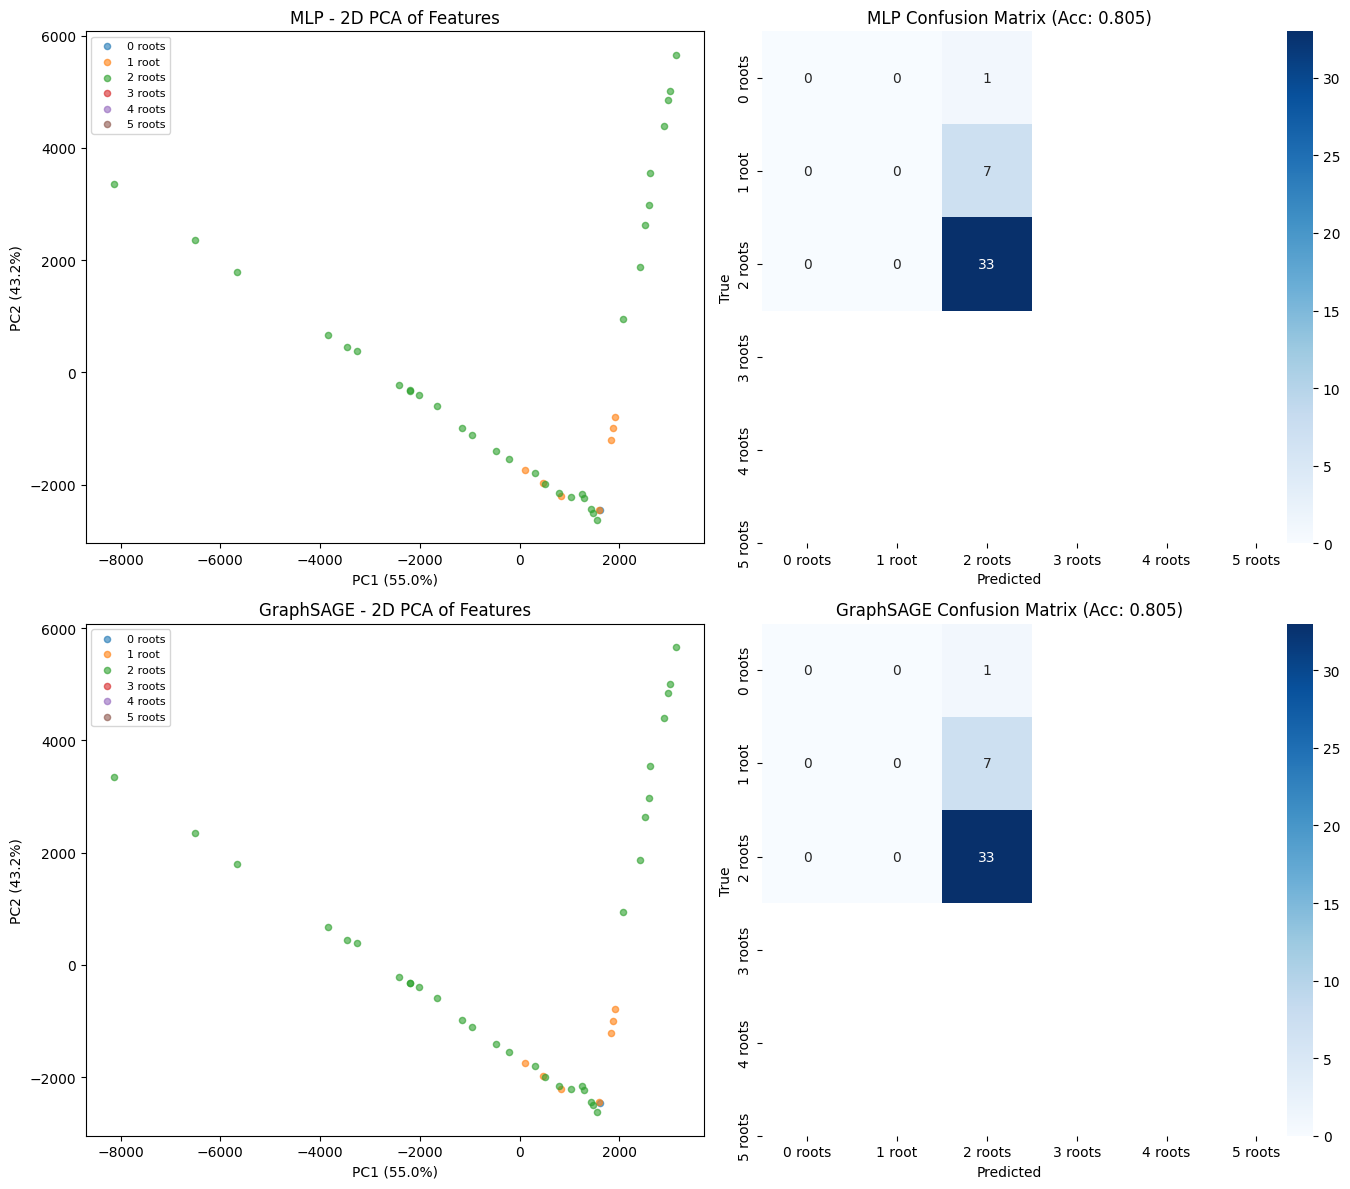


2D Visualization Summary:
- Left column: PCA projection of input features colored by true class
- Right column: Confusion matrices showing prediction accuracy per class


In [23]:
# 2D PCA Embedding Visualization for MLP and GraphSAGE
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

# Try to import seaborn (optional - will use matplotlib fallback if unavailable)
try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except ImportError:
    SEABORN_AVAILABLE = False
    print("Note: seaborn not available, using matplotlib for heatmaps")

def get_model_embeddings(model, data, layer_name='hidden'):
    """Extract embeddings from model's hidden layer."""
    embeddings = {}
    def hook_fn(module, input, output):
        embeddings['h'] = output.detach().cpu().numpy()
    
    # Try different layer names
    for name in [layer_name, 'fc1', 'lin1', 'conv1', 'sage1']:
        if hasattr(model, name):
            handle = getattr(model, name).register_forward_hook(hook_fn)
            break
    else:
        print(f"Warning: Could not find hidden layer in model")
        return None
    
    model.eval()
    with torch.no_grad():
        _ = model(data.x, data.edge_index)
    handle.remove()
    return embeddings.get('h')

# Create figure with 2x2 subplots: PCA + Confusion Matrix for each model
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Generate colors dynamically based on number of classes
num_classes = len(class_names)
if num_classes <= 10:
    cmap = plt.cm.tab10
    colors = [cmap(i) for i in range(num_classes)]
else:
    cmap = plt.cm.tab20
    colors = [cmap(i) for i in range(num_classes)]
class_names = config.CLASS_NAMES
test_mask = trainer.test_mask
y_true = data.y[test_mask].cpu().numpy()

models_to_plot = [
    ('MLP', mlp_model),
    ('GraphSAGE', sage_model)
]

for idx, (name, model) in enumerate(models_to_plot):
    # Get predictions
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        y_pred = logits[test_mask].argmax(dim=1).cpu().numpy()
    
    # PCA on features (since embedding extraction may not work for all models)
    X = data.x[test_mask].cpu().numpy()
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)
    
    # Plot PCA embeddings
    ax = axes[idx, 0]
    for c in range(config.NUM_CLASSES):
        mask = y_true == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], 
                   c=colors[c], label=class_names[c], alpha=0.6, s=20)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'{name} - 2D PCA of Features')
    ax.legend(loc='best', fontsize=8)
    
    # Plot confusion matrix
    ax = axes[idx, 1]
    cm = confusion_matrix(y_true, y_pred)
    
    if SEABORN_AVAILABLE:
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=class_names, yticklabels=class_names)
    else:
        # Matplotlib fallback
        im = ax.imshow(cm, cmap='Blues', aspect='auto')
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names)
        ax.set_yticklabels(class_names)
        # Add text annotations
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                       color='white' if cm[i, j] > cm.max()/2 else 'black')
        plt.colorbar(im, ax=ax)
    
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    accuracy = (y_pred == y_true).mean()
    ax.set_title(f'{name} Confusion Matrix (Acc: {accuracy:.3f})')

plt.tight_layout()
plt.show()

print("\n2D Visualization Summary:")
print("- Left column: PCA projection of input features colored by true class")
print("- Right column: Confusion matrices showing prediction accuracy per class")


## 6.9 Embedding Visualization

Visualize the learned hidden representations (embeddings) from different models to understand how they organize the feature space.

**Models compared:**
- Regression baseline
- CORAL ordinal regression
- DepthAwareGAT classifier
- FocalLossClassifier

**Dimensionality reduction methods:**
- PCA (linear, fast)
- t-SNE (nonlinear, local structure)
- UMAP (nonlinear, global + local structure)


In [24]:
# Try to import UMAP (optional - will fall back to PCA + t-SNE only if unavailable)
UMAP_AVAILABLE = False
try:
    import umap
    UMAP_AVAILABLE = True
    print("✓ UMAP available")
except ImportError as e:
    print(f"⚠ UMAP not available: {e}")
    print("  Will use PCA + t-SNE only (UMAP requires NumPy 2.3 or less)")
    print("  To install compatible UMAP: pip install numba==0.59.1 umap-learn")


✓ UMAP available


In [25]:
def extract_embeddings(model, data, layer_name='conv2'):
    """
    Extract hidden embeddings from a model using forward hook.
    
    Args:
        model: PyTorch model with graph conv layers
        data: PyG Data object with x and edge_index
        layer_name: Name of the layer to extract embeddings from (default: 'conv2')
        
    Returns:
        numpy array of shape [num_nodes, hidden_dim]
    """
    embeddings = {}
    
    def hook_fn(module, input, output):
        embeddings['hidden'] = output.detach()
    
    # Find the target layer
    target_layer = getattr(model, layer_name, None)
    if target_layer is None:
        raise ValueError(f"Model has no layer named '{layer_name}'")
    
    # Register hook
    handle = target_layer.register_forward_hook(hook_fn)
    
    # Run forward pass in eval mode (no dropout)
    model.eval()
    with torch.no_grad():
        _ = model(data.x, data.edge_index)
    
    # Remove hook and return embeddings
    handle.remove()
    return embeddings['hidden'].cpu().numpy()

print("✓ extract_embeddings function defined")


✓ extract_embeddings function defined


In [26]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def reduce_embeddings(H, method='pca', n_components=2, **kwargs):
    """
    Reduce embeddings to 2D or 3D using PCA, t-SNE, or UMAP.
    
    Args:
        H: numpy array of shape [num_nodes, hidden_dim]
        method: 'pca', 'tsne', or 'umap'
        n_components: Number of dimensions to reduce to (2 or 3)
        **kwargs: Additional arguments for the reducer
        
    Returns:
        numpy array of shape [num_nodes, n_components]
    """
    if method == 'pca':
        reducer = PCA(n_components=n_components, random_state=42)
        return reducer.fit_transform(H)
    elif method == 'tsne':
        perplexity = kwargs.get('perplexity', 30)
        reducer = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
        return reducer.fit_transform(H)
    elif method == 'umap':
        if not UMAP_AVAILABLE:
            raise ValueError("UMAP is not available. Install with: pip install numba==0.59.1 umap-learn")
        n_neighbors = kwargs.get('n_neighbors', 15)
        min_dist = kwargs.get('min_dist', 0.1)
        reducer = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
        return reducer.fit_transform(H)
    else:
        raise ValueError(f"Unknown method: {method}")

def get_predictions(model, data, trainer):
    """Get model predictions for all nodes."""
    model.eval()
    with torch.no_grad():
        out = trainer._forward(model)
        if isinstance(out, tuple):
            out = out[0]  # For multitask models
        # Handle CORAL model (sigmoid thresholds)
        if hasattr(model, 'predict_classes'):
            preds = model.predict_classes(data.x, data.edge_index).cpu().numpy()
        else:
            preds = out.argmax(dim=1).cpu().numpy()
    return preds

def plot_model_embeddings(model, model_name, data, trainer, class_names):
    """
    Create embedding visualization for a single model.
    
    Generates a 3xN grid (N=2 or 3 depending on UMAP availability):
    - Rows: True labels, Predicted labels, Errors
    - Columns: PCA, t-SNE, [UMAP if available]
    """
    print(f"\n{'='*70}")
    print(f"Extracting embeddings for {model_name}...")
    print(f"{'='*70}")
    
    # Extract embeddings
    H = extract_embeddings(model, data, layer_name='conv2')
    print(f"  Embedding shape: {H.shape}")
    
    # Get predictions and labels
    y_true = data.y.cpu().numpy()
    y_pred = get_predictions(model, data, trainer)
    
    # Get masks
    train_mask = trainer.train_mask.cpu().numpy()
    val_mask = trainer.val_mask.cpu().numpy()
    test_mask = trainer.test_mask.cpu().numpy()
    
    # Reduce dimensions
    print("  Computing PCA...")
    H_pca = reduce_embeddings(H, method='pca')
    print("  Computing t-SNE...")
    H_tsne = reduce_embeddings(H, method='tsne', perplexity=30)
    
    methods = [('PCA', H_pca), ('t-SNE', H_tsne)]
    
    if UMAP_AVAILABLE:
        print("  Computing UMAP...")
        H_umap = reduce_embeddings(H, method='umap')
        methods.append(('UMAP', H_umap))
    else:
        H_umap = None
        print("  Skipping UMAP (not available)")
    
    # Generate colors dynamically based on number of classes
    num_classes = len(class_names)
    if num_classes <= 10:
        cmap = plt.cm.tab10
        colors = [cmap(i) for i in range(num_classes)]
    else:
        cmap = plt.cm.tab20
        colors = [cmap(i) for i in range(num_classes)]
    
    # Create figure with dynamic number of columns
    n_cols = len(methods)
    fig, axes = plt.subplots(3, n_cols, figsize=(6*n_cols, 15))
    fig.suptitle(f'{model_name} Embeddings', fontsize=16, fontweight='bold')
    
    # Ensure axes is 2D even with 2 columns
    if n_cols == 2:
        axes = axes.reshape(3, 2)
    
    for col, (method_name, H_2d) in enumerate(methods):
        # Row 0: True labels
        ax = axes[0, col]
        for i, class_name in enumerate(class_names):
            mask = y_true == i
            ax.scatter(H_2d[mask, 0], H_2d[mask, 1], c=colors[i], label=class_name, 
                      alpha=0.6, s=10)
        ax.set_title(f'{method_name} - True Labels')
        ax.set_xlabel(f'{method_name} 1')
        ax.set_ylabel(f'{method_name} 2')
        if col == n_cols - 1:  # Last column
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
        
        # Row 1: Predicted labels
        ax = axes[1, col]
        for i, class_name in enumerate(class_names):
            mask = y_pred == i
            ax.scatter(H_2d[mask, 0], H_2d[mask, 1], c=colors[i], label=class_name, 
                      alpha=0.6, s=10)
        ax.set_title(f'{method_name} - Predicted Labels')
        ax.set_xlabel(f'{method_name} 1')
        ax.set_ylabel(f'{method_name} 2')
        if col == n_cols - 1:  # Last column
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
        
        # Row 2: Errors highlighted
        ax = axes[2, col]
        correct = y_true == y_pred
        errors = ~correct
        ax.scatter(H_2d[correct, 0], H_2d[correct, 1], c='#95a5a6', label='Correct', 
                  alpha=0.3, s=8)
        ax.scatter(H_2d[errors, 0], H_2d[errors, 1], c='#e74c3c', label='Errors', 
                  alpha=0.8, s=15, marker='x')
        ax.set_title(f'{method_name} - Errors ({errors.sum()} / {len(errors)})')
        ax.set_xlabel(f'{method_name} 1')
        ax.set_ylabel(f'{method_name} 2')
        if col == n_cols - 1:  # Last column
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
    
    plt.tight_layout()
    plt.show()
    
    # Print accuracy summary
    accuracy = correct.mean()
    print(f"\n  {model_name} Accuracy: {accuracy:.4f} ({correct.sum()}/{len(correct)} correct)")
    
    # Return embeddings (H_umap will be None if UMAP not available)
    return {
        'raw': H,
        'pca': H_pca,
        'tsne': H_tsne,
        'umap': H_umap
    }

print("✓ Visualization functions defined")


✓ Visualization functions defined


In [27]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_model_embeddings_3d(model, model_name, data, trainer, class_names):
    """
    Create interactive 3D embedding visualizations for a single model using Plotly.
    
    Generates 3 interactive 3D scatter plots (PCA, t-SNE, UMAP) showing:
    - Points colored by true class labels
    - Errors marked with different symbols
    - Interactive rotation, zoom, and hover tooltips
    
    Args:
        model: Trained model
        model_name: Name for plot titles
        data: Graph data object
        trainer: Trainer object with masks
        class_names: List of class label names
    """
    print(f"\n{'='*70}")
    print(f"Extracting 3D embeddings for {model_name}...")
    print(f"{'='*70}")
    
    # Extract embeddings
    H = extract_embeddings(model, data, layer_name='conv2')
    print(f"  Embedding shape: {H.shape}")
    
    # Get predictions and labels
    y_true = data.y.cpu().numpy()
    y_pred = get_predictions(model, data, trainer)
    
    # Compute which predictions are correct
    correct = y_true == y_pred
    errors = ~correct
    
    # Get test mask
    test_mask = trainer.test_mask.cpu().numpy()
    
    # Reduce to 3D
    print("  Computing PCA 3D...")
    H_pca_3d = reduce_embeddings(H, method='pca', n_components=3)
    print("  Computing t-SNE 3D...")
    H_tsne_3d = reduce_embeddings(H, method='tsne', n_components=3, perplexity=30)
    
    if UMAP_AVAILABLE:
        print("  Computing UMAP 3D...")
        H_umap_3d = reduce_embeddings(H, method='umap', n_components=3)
        methods = [('PCA', H_pca_3d), ('t-SNE', H_tsne_3d), ('UMAP', H_umap_3d)]
    else:
        print("  Skipping UMAP (not available)")
        methods = [('PCA', H_pca_3d), ('t-SNE', H_tsne_3d)]
    
    # Generate colors dynamically based on number of classes
    num_classes = len(class_names)
    # Convert matplotlib colors to hex for Plotly
    if num_classes <= 10:
        cmap = plt.cm.tab10
    else:
        cmap = plt.cm.tab20
    colors = ['#%02x%02x%02x' % tuple(int(c * 255) for c in cmap(i)[:3]) for i in range(num_classes)]
    
    # Create subplots
    n_methods = len(methods)
    fig = make_subplots(
        rows=1, cols=n_methods,
        subplot_titles=[f'{name} 3D' for name, _ in methods],
        specs=[[{'type': 'scatter3d'}] * n_methods],
        horizontal_spacing=0.05
    )
    
    # For each dimensionality reduction method
    for col_idx, (method_name, H_3d) in enumerate(methods, 1):
        # Plot each class
        for class_idx in range(len(class_names)):
            class_name = class_names[class_idx]
            color = colors[class_idx]
            
            # Correct predictions for this class
            mask_correct = test_mask & (y_true == class_idx) & correct
            if mask_correct.sum() > 0:
                fig.add_trace(
                    go.Scatter3d(
                        x=H_3d[mask_correct, 0],
                        y=H_3d[mask_correct, 1],
                        z=H_3d[mask_correct, 2],
                        mode='markers',
                        name=f'{class_name}',
                        marker=dict(
                            size=4,
                            color=color,
                            opacity=0.7,
                            symbol='circle'
                        ),
                        legendgroup=f'class_{class_idx}',
                        showlegend=(col_idx == 1),  # Only show legend for first plot
                        hovertemplate=f'<b>{class_name}</b><br>' +
                                     'True: %{text}<br>' +
                                     f'{method_name}1: %{{x:.2f}}<br>' +
                                     f'{method_name}2: %{{y:.2f}}<br>' +
                                     f'{method_name}3: %{{z:.2f}}<extra></extra>',
                        text=[class_name] * mask_correct.sum()
                    ),
                    row=1, col=col_idx
                )
            
            # Incorrect predictions for this class
            mask_errors = test_mask & (y_true == class_idx) & errors
            if mask_errors.sum() > 0:
                # Get predicted labels for hover text
                pred_labels = [class_names[p] for p in y_pred[mask_errors]]
                
                fig.add_trace(
                    go.Scatter3d(
                        x=H_3d[mask_errors, 0],
                        y=H_3d[mask_errors, 1],
                        z=H_3d[mask_errors, 2],
                        mode='markers',
                        name=f'{class_name} (error)',
                        marker=dict(
                            size=6,
                            color=color,
                            opacity=0.9,
                            symbol='x',
                            line=dict(color='red', width=2)
                        ),
                        legendgroup=f'class_{class_idx}',
                        showlegend=False,
                        hovertemplate=f'<b>ERROR</b><br>' +
                                     f'True: {class_name}<br>' +
                                     'Pred: %{text}<br>' +
                                     f'{method_name}1: %{{x:.2f}}<br>' +
                                     f'{method_name}2: %{{y:.2f}}<br>' +
                                     f'{method_name}3: %{{z:.2f}}<extra></extra>',
                        text=pred_labels
                    ),
                    row=1, col=col_idx
                )
    
    # Update layout
    fig.update_layout(
        title=dict(
            text=f'<b>{model_name} - 3D Embedding Visualizations</b><br>' +
                 f'<sub>Test Set: {test_mask.sum()} nodes | Accuracy: {correct[test_mask].mean():.4f}</sub>',
            x=0.5,
            xanchor='center'
        ),
        height=600,
        showlegend=True,
        legend=dict(
            orientation="v",
            yanchor="top",
            y=0.98,
            xanchor="left",
            x=1.02,
            font=dict(size=10)
        ),
        margin=dict(l=0, r=150, t=100, b=0)
    )
    
    # Update 3D scene properties for all subplots
    for i in range(1, n_methods + 1):
        fig.update_scenes(
            dict(
                xaxis=dict(title='Dim 1', backgroundcolor="rgb(240, 240, 240)", gridcolor="white"),
                yaxis=dict(title='Dim 2', backgroundcolor="rgb(240, 240, 240)", gridcolor="white"),
                zaxis=dict(title='Dim 3', backgroundcolor="rgb(240, 240, 240)", gridcolor="white"),
                camera=dict(
                    eye=dict(x=1.5, y=1.5, z=1.5)
                )
            ),
            row=1, col=i
        )
    
    fig.show()
    
    # Print summary
    accuracy = correct[test_mask].mean()
    print(f"\n  {model_name} Test Accuracy: {accuracy:.4f} ({correct[test_mask].sum()}/{test_mask.sum()} correct)")
    print(f"  Errors: {errors[test_mask].sum()} nodes")
    
    return {
        'pca_3d': H_pca_3d,
        'tsne_3d': H_tsne_3d,
        'umap_3d': H_umap_3d if UMAP_AVAILABLE else None
    }

print("✓ 3D Visualization function defined")

✓ 3D Visualization function defined


EMBEDDING VISUALIZATIONS

This will generate 3x3 plots for each model showing:
  - Row 1: True labels colored by class
  - Row 2: Predicted labels colored by class
  - Row 3: Errors highlighted in red
  - Columns: PCA, t-SNE, UMAP


1. REGRESSION MODEL

Extracting embeddings for Regression Baseline...
  Embedding shape: (206, 64)
  Computing PCA...
  Computing t-SNE...
  Computing UMAP...


c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\tomas\AppData\Local\Temp\ipykernel_26888\3280314944.py:112: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(H_2d[mask, 0], H_2d[mask, 1], c=colors[i], label=class_name,
C:\Users\tomas\AppData\Local\Temp\ipykernel_26888\3280314944.py:124: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you i

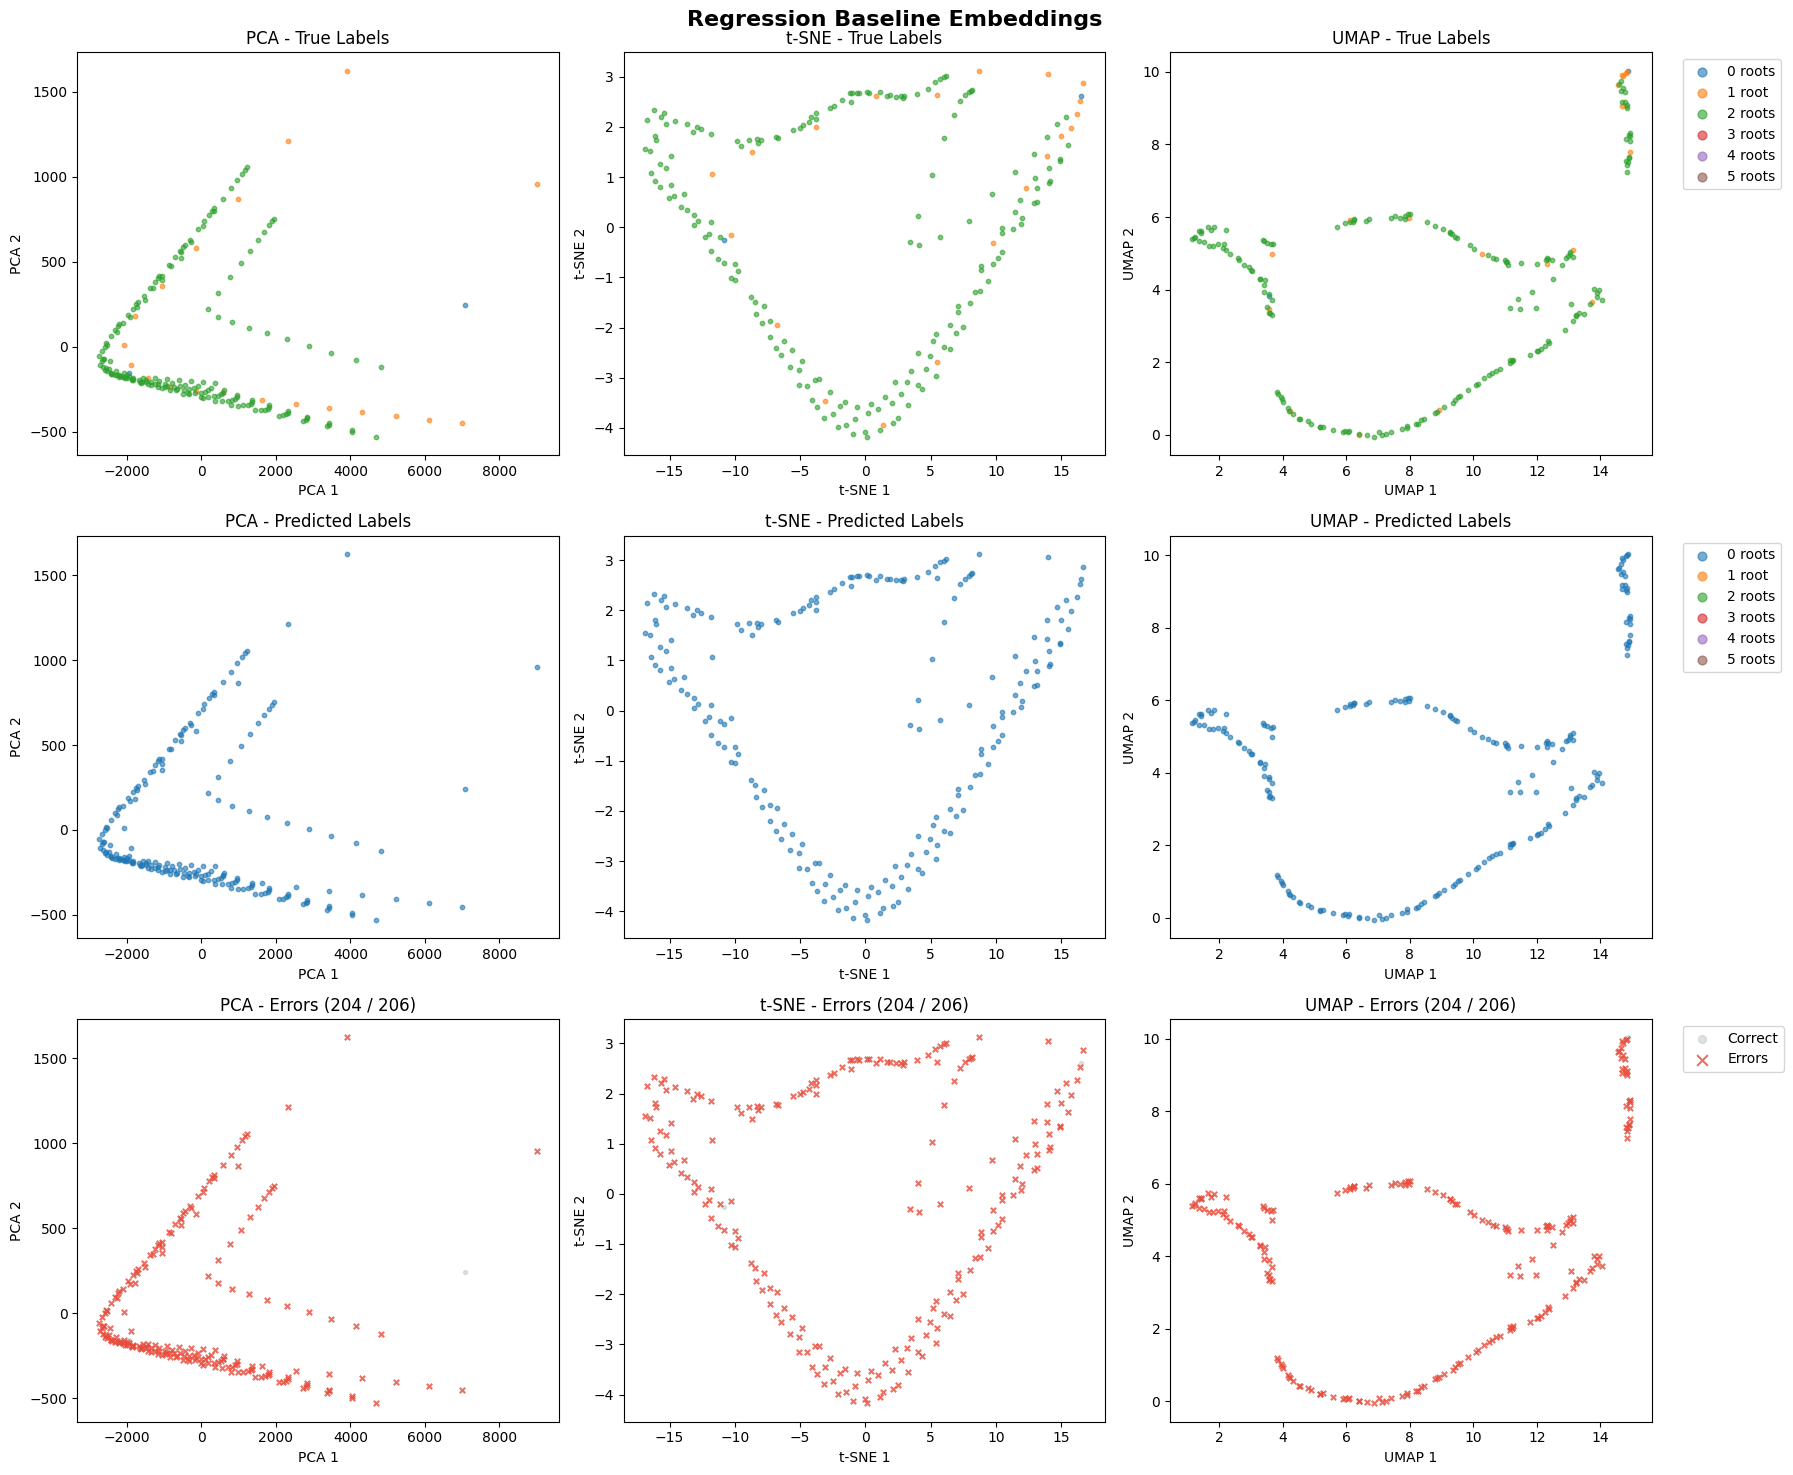


  Regression Baseline Accuracy: 0.0097 (2/206 correct)

2. CORAL MODEL

Extracting embeddings for CORAL Ordinal Regression...
  Embedding shape: (206, 64)
  Computing PCA...
  Computing t-SNE...
  Computing UMAP...


c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\tomas\AppData\Local\Temp\ipykernel_26888\3280314944.py:112: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(H_2d[mask, 0], H_2d[mask, 1], c=colors[i], label=class_name,
C:\Users\tomas\AppData\Local\Temp\ipykernel_26888\3280314944.py:124: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you i

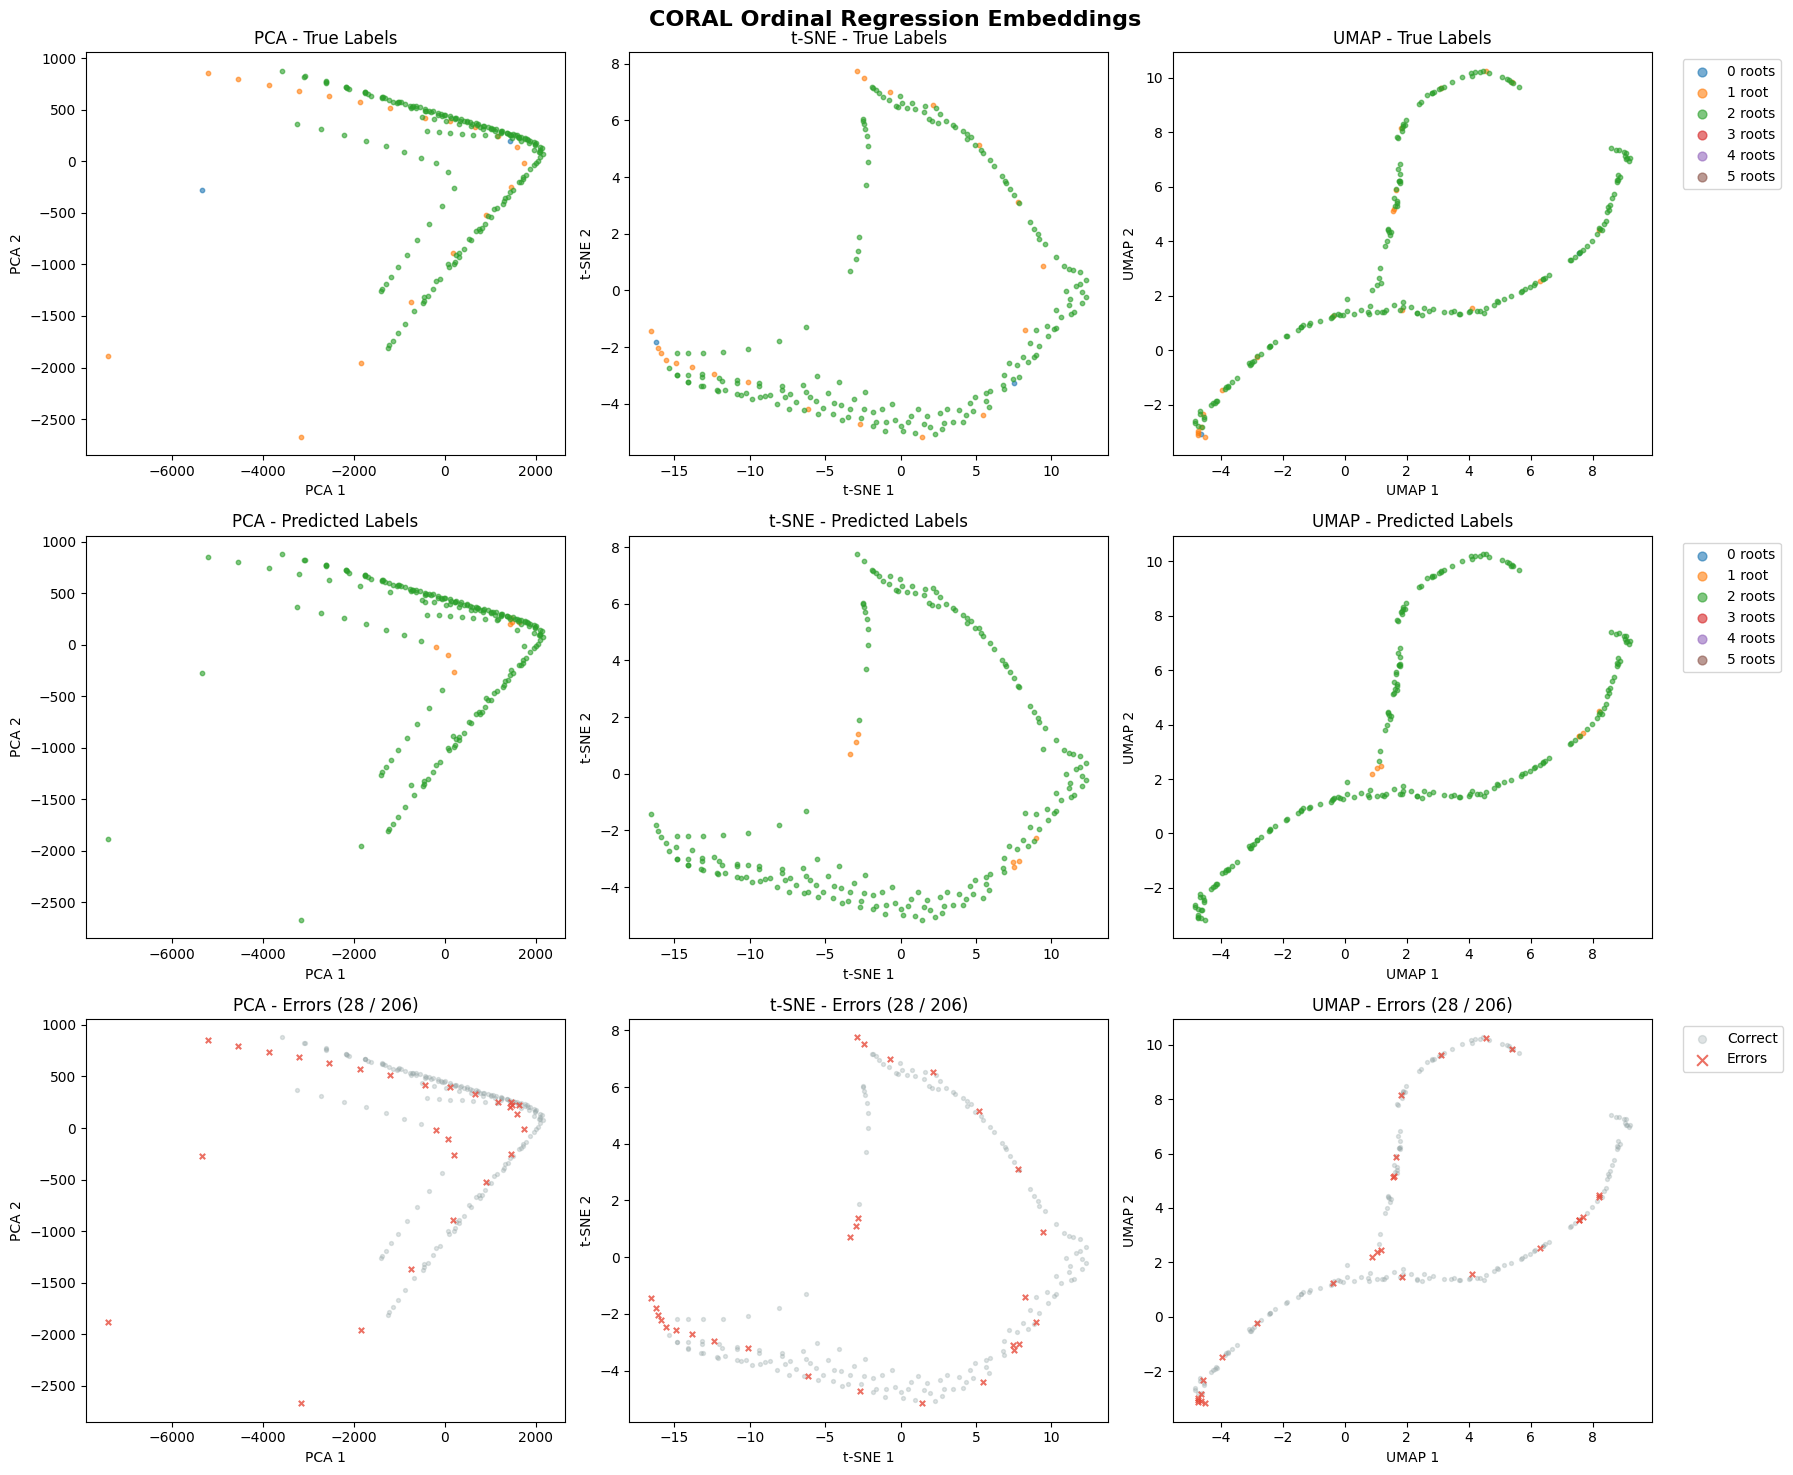


  CORAL Ordinal Regression Accuracy: 0.8641 (178/206 correct)

3. DEPTH-AWARE GAT MODEL

Extracting embeddings for DepthAwareGAT...
  Embedding shape: (206, 256)
  Computing PCA...
  Computing t-SNE...
  Computing UMAP...


c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\tomas\AppData\Local\Temp\ipykernel_26888\3280314944.py:112: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(H_2d[mask, 0], H_2d[mask, 1], c=colors[i], label=class_name,
C:\Users\tomas\AppData\Local\Temp\ipykernel_26888\3280314944.py:124: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you i

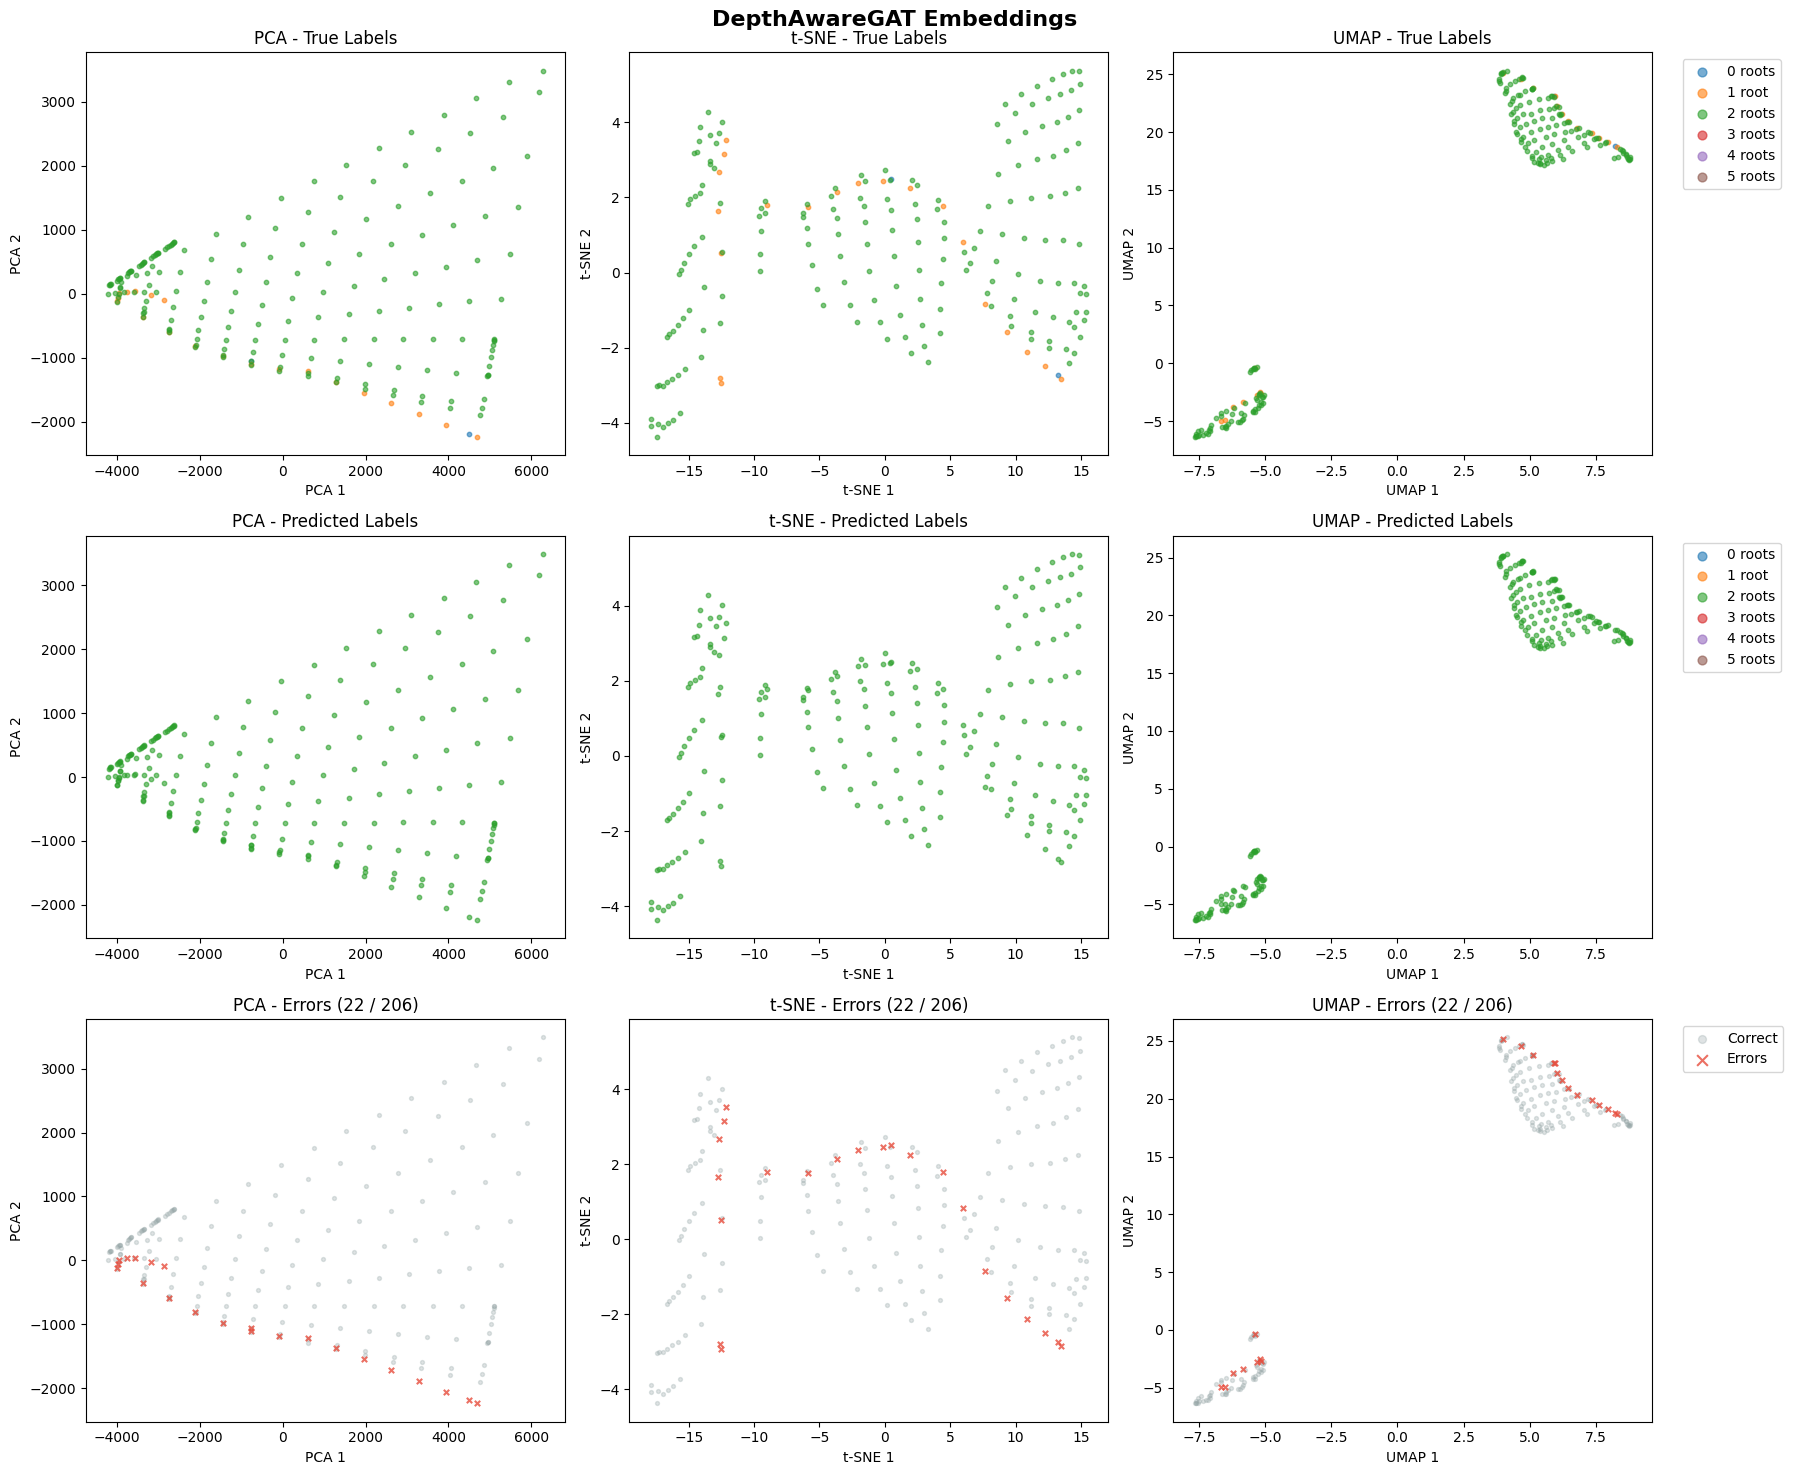


  DepthAwareGAT Accuracy: 0.8932 (184/206 correct)

4. FOCAL LOSS MODEL

Extracting embeddings for FocalLossClassifier...
  Embedding shape: (206, 256)
  Computing PCA...
  Computing t-SNE...
  Computing UMAP...


c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\tomas\AppData\Local\Temp\ipykernel_26888\3280314944.py:112: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(H_2d[mask, 0], H_2d[mask, 1], c=colors[i], label=class_name,
C:\Users\tomas\AppData\Local\Temp\ipykernel_26888\3280314944.py:124: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you i

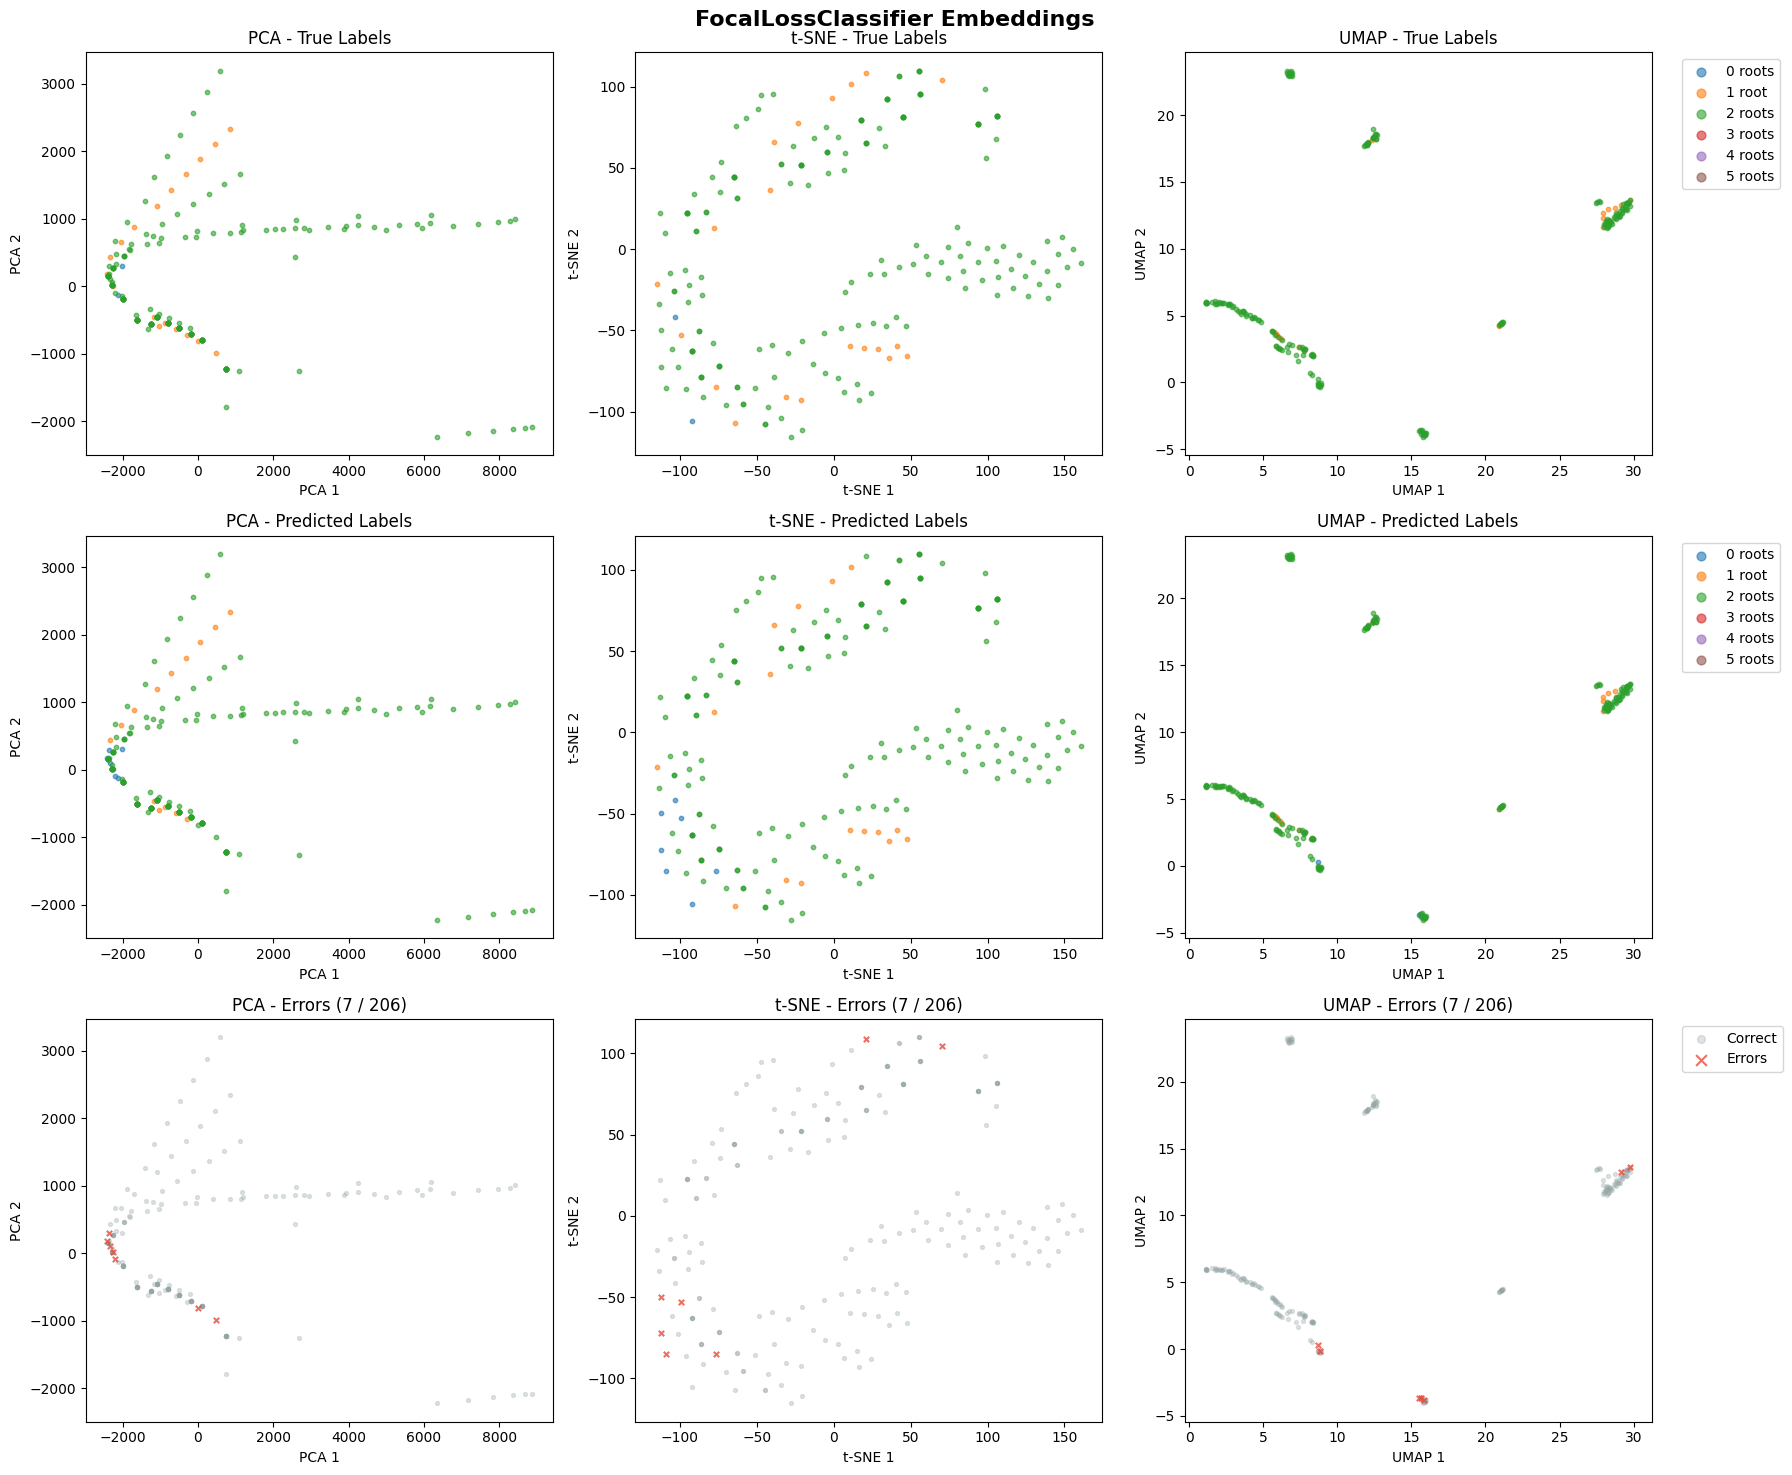


  FocalLossClassifier Accuracy: 0.9660 (199/206 correct)

✓ All embedding visualizations complete!


In [28]:
# Generate embedding visualizations for all 4 models
# Models: reg_model, coral_model, gat_model, focal_model

print("=" * 70)
print("EMBEDDING VISUALIZATIONS")
print("=" * 70)
print("\nThis will generate 3x3 plots for each model showing:")
print("  - Row 1: True labels colored by class")
print("  - Row 2: Predicted labels colored by class")
print("  - Row 3: Errors highlighted in red")
print("  - Columns: PCA, t-SNE, UMAP\n")

# Get class names from config
class_names = config.CLASS_NAMES

# 1. Regression Model
print("\n" + "=" * 70)
print("1. REGRESSION MODEL")
print("=" * 70)
reg_embeddings = plot_model_embeddings(reg_model, "Regression Baseline", data, trainer, class_names)

# 2. CORAL Model
print("\n" + "=" * 70)
print("2. CORAL MODEL")
print("=" * 70)
coral_embeddings = plot_model_embeddings(coral_model, "CORAL Ordinal Regression", data, trainer, class_names)

# 3. DepthAwareGAT Model
print("\n" + "=" * 70)
print("3. DEPTH-AWARE GAT MODEL")
print("=" * 70)
gat_embeddings = plot_model_embeddings(gat_model, "DepthAwareGAT", data, trainer, class_names)

# 4. Focal Loss Model
print("\n" + "=" * 70)
print("4. FOCAL LOSS MODEL")
print("=" * 70)
focal_embeddings = plot_model_embeddings(focal_model, "FocalLossClassifier", data, trainer, class_names)

print("\n" + "=" * 70)
print("✓ All embedding visualizations complete!")
print("=" * 70)


## 3D Interactive Embedding Visualizations

Now let's visualize the same embeddings in **interactive 3D** using Plotly. These visualizations allow you to:
- **Rotate** the 3D space by clicking and dragging
- **Zoom** in/out with mouse wheel
- **Hover** over points to see node details
- **Compare** how different dimensionality reduction methods (PCA, t-SNE, UMAP) separate classes in 3D

Each visualization shows:
- **Colored points** = correctly classified nodes (by true class)
- **X markers with red outline** = incorrectly classified nodes (errors)
- **3 subplots** = PCA 3D, t-SNE 3D, UMAP 3D

In [29]:
# 1. Regression Model - 3D Visualization
print("\n" + "="*70)
print("3D VISUALIZATION - REGRESSION MODEL")
print("="*70)
reg_embeddings_3d = plot_model_embeddings_3d(reg_model, "Regression Baseline", data, trainer, class_names)


3D VISUALIZATION - REGRESSION MODEL

Extracting 3D embeddings for Regression Baseline...
  Embedding shape: (206, 64)
  Computing PCA 3D...
  Computing t-SNE 3D...
  Computing UMAP 3D...


c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



  Regression Baseline Test Accuracy: 0.0244 (1/41 correct)
  Errors: 40 nodes


## 6.10 Interactive 3D Embedding Visualizations

Interactive 3D visualizations using Plotly that encode:
- **Color**: True root count (ground truth label)
- **Marker size**: Prediction confidence or entropy
- **Interactivity**: Rotate, zoom, and hover for details

These visualizations help answer key analytical questions about the learned representations.


In [30]:
# 3. DepthAwareGAT Model - 3D Visualization
print("\n" + "="*70)
print("3D VISUALIZATION - DEPTH-AWARE GAT")
print("="*70)
gat_embeddings_3d = plot_model_embeddings_3d(gat_model, "DepthAwareGAT", data, trainer, class_names)


3D VISUALIZATION - DEPTH-AWARE GAT

Extracting 3D embeddings for DepthAwareGAT...
  Embedding shape: (206, 256)
  Computing PCA 3D...
  Computing t-SNE 3D...
  Computing UMAP 3D...


c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




  DepthAwareGAT Test Accuracy: 0.8049 (33/41 correct)
  Errors: 8 nodes


In [31]:
# 4. Focal Loss Model - 3D Visualization
print("\n" + "="*70)
print("3D VISUALIZATION - FOCAL LOSS CLASSIFIER")
print("="*70)
focal_embeddings_3d = plot_model_embeddings_3d(focal_model, "FocalLossClassifier", data, trainer, class_names)

print("\n" + "="*70)
print("✓ All 3D embedding visualizations complete!")
print("="*70)


3D VISUALIZATION - FOCAL LOSS CLASSIFIER

Extracting 3D embeddings for FocalLossClassifier...
  Embedding shape: (206, 256)
  Computing PCA 3D...
  Computing t-SNE 3D...
  Computing UMAP 3D...


c:\Users\tomas\JavaProjects\Aibeceles\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




  FocalLossClassifier Test Accuracy: 0.9268 (38/41 correct)
  Errors: 3 nodes

✓ All 3D embedding visualizations complete!


In [32]:
import plotly.express as px
import plotly.graph_objects as go
import torch.nn.functional as F

def compute_confidence_and_entropy(model, data, trainer):
    """
    Compute prediction confidence and entropy for all nodes.
    
    Args:
        model: Trained model
        data: PyTorch Geometric data object
        trainer: NodeClassificationTrainer instance
        
    Returns:
        dict with 'confidence' and 'entropy' numpy arrays
    """
    model.eval()
    with torch.no_grad():
        out = trainer._forward(model)
        if isinstance(out, tuple):
            out = out[0]  # For multitask models
        
        # Handle CORAL model separately (sigmoid outputs)
        if hasattr(model, 'predict_classes'):
            # For CORAL, use cumulative probabilities as proxy
            probs = torch.sigmoid(out)
            confidence = probs.max(dim=1).values.cpu().numpy()
            # Entropy approximation for ordinal
            entropy = -(probs * torch.log(probs + 1e-8) + 
                       (1 - probs) * torch.log(1 - probs + 1e-8)).mean(dim=1).cpu().numpy()
        else:
            # Standard softmax models
            probs = F.softmax(out, dim=1)
            confidence = probs.max(dim=1).values.cpu().numpy()
            # Shannon entropy: -sum(p * log(p))
            entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1).cpu().numpy()
    
    return {
        'confidence': confidence,
        'entropy': entropy,
        'probs': probs.cpu().numpy()
    }


def plot_3d_embeddings(H, y_true, y_pred, confidence, entropy, title, class_names):
    """
    Create interactive 3D scatter plots using Plotly.
    
    Args:
        H: Embeddings of shape [num_nodes, hidden_dim]
        y_true: Ground truth labels
        y_pred: Predicted labels
        confidence: Confidence scores per node
        entropy: Entropy scores per node
        title: Plot title
        class_names: List of class names
    """
    # Reduce to 3D using PCA
    H_3d = reduce_embeddings(H, method='pca', n_components=3)
    
    # Create DataFrame for Plotly
    import pandas as pd
    df = pd.DataFrame({
        'PC1': H_3d[:, 0],
        'PC2': H_3d[:, 1],
        'PC3': H_3d[:, 2],
        'True Root Count': [class_names[y] for y in y_true],
        'Predicted': [class_names[y] for y in y_pred],
        'Confidence': confidence,
        'Entropy': entropy,
        'Correct': y_true == y_pred
    })
    
    # Normalize marker sizes (confidence)
    size_conf = (confidence - confidence.min()) / (confidence.max() - confidence.min() + 1e-8)
    size_conf = 3 + size_conf * 12  # Scale to range [3, 15]
    
    # Normalize marker sizes (entropy - larger = more uncertain)
    size_ent = (entropy - entropy.min()) / (entropy.max() - entropy.min() + 1e-8)
    size_ent = 3 + size_ent * 12  # Scale to range [3, 15]
    
    # Color palette matching matplotlib
    color_map = {
        class_names[0]: '#e74c3c',  # 0 roots - red
        class_names[1]: '#3498db',  # 1 root - blue
        class_names[2]: '#2ecc71',  # 2 roots - green
        class_names[3]: '#f39c12',  # 3 roots - orange
        class_names[4]: '#9b59b6',  # 4 roots - purple
    }
    
    # Plot 1: Color by true label, size by confidence
    fig1 = px.scatter_3d(
        df,
        x='PC1', y='PC2', z='PC3',
        color='True Root Count',
        color_discrete_map=color_map,
        size=size_conf,
        hover_data=['Predicted', 'Confidence', 'Entropy', 'Correct'],
        title=f'{title} - Color: True Labels, Size: Confidence',
        opacity=0.7
    )
    fig1.update_layout(
        scene=dict(
            xaxis_title='PC1',
            yaxis_title='PC2',
            zaxis_title='PC3'
        ),
        width=900, height=700
    )
    fig1.show()
    
    # Plot 2: Color by true label, size by entropy (uncertainty)
    fig2 = px.scatter_3d(
        df,
        x='PC1', y='PC2', z='PC3',
        color='True Root Count',
        color_discrete_map=color_map,
        size=size_ent,
        hover_data=['Predicted', 'Confidence', 'Entropy', 'Correct'],
        title=f'{title} - Color: True Labels, Size: Entropy (Uncertainty)',
        opacity=0.7
    )
    fig2.update_layout(
        scene=dict(
            xaxis_title='PC1',
            yaxis_title='PC2',
            zaxis_title='PC3'
        ),
        width=900, height=700
    )
    fig2.show()
    
    # Plot 3: Highlight errors
    df['Status'] = df['Correct'].map({True: 'Correct', False: 'Error'})
    fig3 = px.scatter_3d(
        df,
        x='PC1', y='PC2', z='PC3',
        color='Status',
        color_discrete_map={'Correct': '#95a5a6', 'Error': '#e74c3c'},
        size=size_conf,
        hover_data=['True Root Count', 'Predicted', 'Confidence', 'Entropy'],
        title=f'{title} - Errors Highlighted (Size: Confidence)',
        opacity=0.7
    )
    fig3.update_layout(
        scene=dict(
            xaxis_title='PC1',
            yaxis_title='PC2',
            zaxis_title='PC3'
        ),
        width=900, height=700
    )
    fig3.show()
    
    return H_3d

print("✓ 3D visualization helper functions defined")


✓ 3D visualization helper functions defined


In [33]:
# Generate interactive 3D visualizations for the best model (GAT)
print("=" * 70)
print("INTERACTIVE 3D EMBEDDING VISUALIZATIONS")
print("=" * 70)
print("\nGenerating 3D PCA projections with:")
print("  - Color = True root count")
print("  - Marker size = Confidence or Entropy")
print("  - Hover for details, rotate/zoom to explore\n")

# Extract embeddings and compute confidence/entropy for GAT model
H_gat = extract_embeddings(gat_model, data, layer_name='conv2')
conf_ent_gat = compute_confidence_and_entropy(gat_model, data, trainer)
y_true = data.y.cpu().numpy()
y_pred_gat = get_predictions(gat_model, data, trainer)

# Create 3D visualizations
H_3d_gat = plot_3d_embeddings(
    H_gat, y_true, y_pred_gat,
    conf_ent_gat['confidence'], conf_ent_gat['entropy'],
    'DepthAwareGAT', class_names
)

print("\n" + "=" * 70)
print("✓ Interactive 3D visualizations complete!")
print("=" * 70)


INTERACTIVE 3D EMBEDDING VISUALIZATIONS

Generating 3D PCA projections with:
  - Color = True root count
  - Marker size = Confidence or Entropy
  - Hover for details, rotate/zoom to explore




✓ Interactive 3D visualizations complete!


### Analytical Questions

Use the interactive 3D plots above to answer these questions:

1. **Along which axis (PC1, PC2, PC3) does root count actually change?**
   - Rotate the plot to find axes where colors separate cleanly
   - This reveals which principal components capture root count information

2. **Do high-confidence predictions cluster differently than low-confidence ones?**
   - Look at marker sizes - are large markers (high confidence) clustered or scattered?
   - Are low-confidence points at decision boundaries?

3. **Where do misclassifications concentrate in 3D space?**
   - In the error plot, are red X's clustered in specific regions?
   - Do errors occur at class boundaries or randomly throughout?

4. **Is there a confidence threshold where accuracy drops sharply?**
   - Hover over errors to check their confidence values
   - Are most errors low-confidence or some high-confidence too?

5. **Which classes overlap the most in embedding space?**
   - Look for colors that mix together vs. separate cleanly
   - This explains which root counts are hardest to distinguish


## 7. Generate and Analyze Predictions


In [34]:
# Initialize predictor
predictor = NodePredictor(gat_model, data)

# Generate predictions
predictions = predictor.predict()

# Get prediction statistics
pred_stats = predictor.get_prediction_stats()
print("Prediction Statistics:")
print(f"  Total nodes: {pred_stats['total_nodes']:,}")
print(f"\n  Predicted root count distribution:")
for root_count, count in sorted(pred_stats['class_distribution'].items()):
    pct = count / pred_stats['total_nodes'] * 100
    print(f"    {root_count} roots: {count:>8,} ({pct:>5.1f}%)")
print(f"\n  Mean confidence: {pred_stats['mean_confidence']:.4f}")


Prediction Statistics:
  Total nodes: 206

  Predicted root count distribution:
    2 roots:      206 (100.0%)

  Mean confidence: 1.0000


In [35]:
# Compare with ground truth
comparison = predictor.compare_with_ground_truth()

print("Comparison with Ground Truth:")
print(f"  Overall Accuracy: {comparison['accuracy']:.4f}")
print(f"  MAE: {comparison['mae']:.4f} roots")
print(f"\n  Per-class accuracy (important for imbalanced data):")
for root_count, acc in sorted(comparison['class_accuracies'].items()):
    label = f"{root_count} roots"
    print(f"    {label}: {acc:.4f}")


Comparison with Ground Truth:
  Overall Accuracy: 0.8932
  MAE: 0.1165 roots

  Per-class accuracy (important for imbalanced data):
    0 roots: 0.0000
    1 roots: 0.0000
    2 roots: 1.0000


## 7.5 Save Evaluation Metrics

Save all model metrics to `evaluation_metrics` folder for comparison with future runs.

In [36]:
import json
from datetime import datetime
from pathlib import Path
import pandas as pd

# Create evaluation_metrics directory
metrics_dir = Path('evaluation_metrics')
metrics_dir.mkdir(exist_ok=True)

# Timestamp for this run
timestamp = datetime.now()
run_id = timestamp.strftime("%Y%m%d_%H%M%S")

print("=" * 70)
print("SAVING EVALUATION METRICS")
print("=" * 70)

# Collect all available model metrics (handles partial runs)
all_models = {
    'Full-batch GAT (CE)': globals().get('gat_metrics'),
    'DepthAwareGATv2': globals().get('gat_v2_metrics'),
    'Focal Loss': globals().get('focal_metrics'),
    'MLP': globals().get('mlp_metrics'),
    'GraphSAGE': globals().get('sage_metrics'),
    'Regression': globals().get('reg_metrics'),
    'CORAL': globals().get('coral_metrics'),
    'Full-batch GAT (EMD)': globals().get('emd_metrics'),
}

# Filter out None values (models that weren't trained)
trained_models = {name: metrics for name, metrics in all_models.items() if metrics is not None}

print(f"\nFound {len(trained_models)} trained model(s):")
for name in trained_models.keys():
    print(f"  - {name}")

# Extract metrics from trained models
models_data = {}
for name, metrics in trained_models.items():
    models_data[name] = {
        'test_macro_f1': float(metrics.get('test_macro_f1', 0)),
        'test_balanced_acc': float(metrics.get('test_balanced_acc', 0)),
        'test_mae': float(metrics.get('test_mae', 0)),
        'test_f1_weighted': float(metrics.get('test_f1', 0))
    }

# Find best model by MAE (lower is better)
best_model_name = None
best_mae = float('inf')
if models_data:
    for name, metrics in models_data.items():
        if metrics['test_mae'] < best_mae:
            best_mae = metrics['test_mae']
            best_model_name = name

# Get dataset statistics if available
dataset_stats = {}
if 'stats' in globals():
    stats_obj = globals()['stats']
    dataset_stats = {
        'num_nodes': int(stats_obj.get('num_nodes', 0)),
        'num_edges': int(stats_obj.get('num_edges', 0)),
        'num_features': int(stats_obj.get('num_features', 0)),
        'density': float(stats_obj.get('density', 0)),
        'class_distribution': {str(k): int(v) for k, v in stats_obj.get('class_distribution', {}).items()}
    }

# Get predictor comparison if available
predictor_data = {}
if 'comparison' in globals():
    comp = globals()['comparison']
    predictor_data = {
        'accuracy': float(comp.get('accuracy', 0)),
        'mae': float(comp.get('mae', 0)),
        'class_accuracies': {str(k): float(v) for k, v in comp.get('class_accuracies', {}).items()}
    }

# Build comprehensive metrics snapshot
metrics_snapshot = {
    'timestamp': timestamp.isoformat(),
    'run_id': run_id,
    'dataset_stats': dataset_stats,
    'models': models_data,
    'best_model': {
        'name': best_model_name,
        'mae': best_mae
    } if best_model_name else None,
    'predictor_comparison': predictor_data if predictor_data else None
}

# Save as JSON with pretty formatting
output_file = metrics_dir / f'metrics_{run_id}.json'
with open(output_file, 'w') as f:
    json.dump(metrics_snapshot, f, indent=2)

print(f"\n✓ Metrics saved to: {output_file.absolute()}")

# Also append to cumulative log (JSONL format for easy parsing)
log_file = metrics_dir / 'metrics_history.jsonl'
with open(log_file, 'a') as f:
    f.write(json.dumps(metrics_snapshot) + '\n')

print(f"✓ History updated: {log_file.absolute()}")

# Save comparison table as CSV if models were trained
if models_data:
    comparison_data = []
    for name, metrics in models_data.items():
        comparison_data.append({
            'Model': name,
            'Macro F1': metrics['test_macro_f1'],
            'Balanced Acc': metrics['test_balanced_acc'],
            'MAE': metrics['test_mae'],
            'Weighted F1': metrics['test_f1_weighted']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('MAE')  # Sort by MAE (best first)
    
    csv_file = metrics_dir / f'model_comparison_{run_id}.csv'
    comparison_df.to_csv(csv_file, index=False)
    
    print(f"✓ Comparison table: {csv_file.absolute()}")
    print("\nModel Rankings (by MAE):")
    print(comparison_df.to_string(index=False))

print("\n" + "=" * 70)
print(f"✓ All evaluation metrics saved to: {metrics_dir.absolute()}")
print("=" * 70)

SAVING EVALUATION METRICS

Found 8 trained model(s):
  - Full-batch GAT (CE)
  - DepthAwareGATv2
  - Focal Loss
  - MLP
  - GraphSAGE
  - Regression
  - CORAL
  - Full-batch GAT (EMD)

✓ Metrics saved to: c:\Users\tomas\JavaProjects\Aibeceles\ml\graph_label_prediction\workbooks\evaluation_metrics\metrics_20260210_144218.json
✓ History updated: c:\Users\tomas\JavaProjects\Aibeceles\ml\graph_label_prediction\workbooks\evaluation_metrics\metrics_history.jsonl
✓ Comparison table: c:\Users\tomas\JavaProjects\Aibeceles\ml\graph_label_prediction\workbooks\evaluation_metrics\model_comparison_20260210_144218.csv

Model Rankings (by MAE):
               Model  Macro F1  Balanced Acc      MAE  Weighted F1
          Focal Loss  0.767677      0.894661 0.097561     0.934959
 Full-batch GAT (CE)  0.297297      0.333333 0.219512     0.717864
                 MLP  0.297297      0.333333 0.219512     0.717864
           GraphSAGE  0.297297      0.333333 0.219512     0.717864
Full-batch GAT (EMD)  0.2972

## 8. Cleanup


In [37]:
# Close Neo4j connection
client.close()
print("✓ Neo4j connection closed")


✓ Neo4j connection closed
